# SIEM exploration — synthetic OCSF dataset

This notebook does four kinds of analysis against the synthetic OCSF
dataset generated by `scripts/generate_synthetic_data.py`:

1. **Capacity / volume** — events per class / day / hour; cardinality.
2. **Threat hunting** — failed-auth patterns, top bad IPs, cross-source
   pivots, find the 5 injected incident scenarios.
3. **Detection-rule prototyping** — Sigma-style rules in pandas:
   brute force, off-hours admin, Vault permission spikes, multi-region
   API activity.
4. **Compliance evidence** — severity distribution, MITRE coverage,
   audit completeness.

## Regenerating the dataset

```bash
# Default: 30 days, ~5 GB Parquet (scale=8). Adjust --scale up or down.
python3 scripts/generate_synthetic_data.py --scale 8 --out data/synthetic/ocsf

# Quick smoke test (~50 MB, finishes in seconds):
python3 scripts/generate_synthetic_data.py --scale 0.05 --out data/synthetic/ocsf
```

Output layout: `data/synthetic/ocsf/class_uid=NNNN/event_day=YYYY-MM-DD/part-*.parquet`
— Hive-partitioned, auto-discoverable by `pyarrow.dataset`.

## Injected anomalies (so the notebook has signal to find)

| Scenario | When | What |
|---|---|---|
| Brute-force burst | Day 14, 12:00 UTC | 200 failed sshd attempts on `carol@corp.example.com` from `185.220.101.42`, plus 1 successful login |
| GuardDuty critical chain | Day 20, 09:00 UTC | severity 5 finding → PagerDuty triggered → ack 10m → resolved 2h |
| Vault permission-denied spike | Day 10, 14:00 UTC | 50 denied secret reads by `rogue-svc-account` from `45.155.205.7` |
| Lateral movement | Day 5, 23:00 UTC | One principal hitting AWS APIs across 5 regions within 10 minutes |
| MFA fraud cluster | Day 25, 03:00 UTC | 8 Duo `fraud` results across 5 users — exec-targeted, from `185.220.101.x` |


## Setup

In [1]:
# Standard analytical stack — pyarrow.dataset for the Hive-partitioned read,
# pandas for the filter/group/aggregate dance, matplotlib for the charts.
import pyarrow.dataset as ds
import pyarrow as pa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timezone
from pathlib import Path

# Repo-rooted dataset path. Override DATA_ROOT if you generated elsewhere.
DATA_ROOT = Path("../data/synthetic/ocsf")
if not DATA_ROOT.is_dir():
    DATA_ROOT = Path("data/synthetic/ocsf")  # if running from repo root
assert DATA_ROOT.is_dir(), f"No dataset at {DATA_ROOT}. Run scripts/generate_synthetic_data.py first."

# Explicit partition typing — pyarrow's auto-inference picks int32 for
# small class_uids and int64 for larger ones (like 201001 for the Windows
# extension), which then can't merge cross-partition. Fix the types
# up-front and the dataset loads cleanly.
DS = ds.dataset(
    DATA_ROOT, format="parquet",
    partitioning=ds.partitioning(
        pa.schema([("class_uid", pa.int64()), ("event_day", pa.string())]),
        flavor="hive",
    ),
)
print(f"Dataset: {DATA_ROOT}")
print(f"Schema (top): {[f.name for f in DS.schema][:20]}...")
print(f"Partition keys: {[f.name for f in DS.schema if f.name in ('class_uid', 'event_day')]}")

def safe_read(dataset, columns, **kwargs):
    """Defensive cross-class read. Schemas differ per OCSF class — a
    File-System-Activity row has `file` but no `user`; an Authentication
    row has `user` but no `file`. Filter to the columns pyarrow knows
    about, NaN-pad the rest so downstream code can ``.apply(...)`` blindly."""
    available = set(dataset.schema.names)
    keep = [c for c in columns if c in available]
    df = dataset.to_table(columns=keep, **kwargs).to_pandas()
    for c in columns:
        if c not in df.columns:
            df[c] = None
    return df


Dataset: ../data/synthetic/ocsf
Schema (top): ['metadata', 'time', 'category_uid', 'category_name', 'class_uid', 'class_name', 'activity_id', 'activity_name', 'type_uid', 'severity_id', 'severity', 'device', 'actor', 'file', 'raw_data', 'event_day']...
Partition keys: ['class_uid', 'event_day']


## Phase A — Pre-aggregate to fast tables

5 GB of raw OCSF events × nested-struct columns balloons to ~20-30 GB
in pandas because of object overhead. Cross-class queries on the raw
swap-thrash and never finish.

The cells below build a handful of **small Parquet aggregates** under
`data/synthetic/agg/`. Each one is computed via **class-by-class
filtering** (so we never materialize the full 5 GB into memory at
once) and stored as a flat table — primitives only, no nested
structs. Subsequent cells read these aggregates in milliseconds.

**Idempotent** — re-running the notebook skips aggregates that
already exist on disk. Force a rebuild by deleting `data/synthetic/agg/`.


In [2]:
# Aggregator infrastructure — output dir + idempotent build helper.
import time
import pyarrow.parquet as pq
AGG_ROOT = DATA_ROOT.parent / "agg"
AGG_ROOT.mkdir(parents=True, exist_ok=True)

def build_if_missing(name, builder, *, force=False):
    """Build ``builder()`` and write to AGG_ROOT/name; skip if it exists."""
    path = AGG_ROOT / f"{name}.parquet"
    if path.exists() and not force:
        df = pd.read_parquet(path)
        print(f"  ✓ {name:<28} loaded  ({len(df):>10,} rows, {path.stat().st_size/1024/1024:>6.1f} MB)")
        return df
    t0 = time.time()
    df = builder()
    df.to_parquet(path, compression="snappy", index=False)
    print(f"  ✓ {name:<28} built    ({len(df):>10,} rows, {path.stat().st_size/1024/1024:>6.1f} MB, {time.time()-t0:>4.1f}s)")
    return df

def _scan_class(class_uid, columns, sample_pct=100):
    """Read one class's partition with only the columns it actually has.
    ``sample_pct < 100`` reads a random N% of the class's part files —
    necessary for big classes (3002, 6003, 4002, 4001) where the full
    scan materialises tens of millions of struct-bearing rows into pandas.

    Sample is per-file (not per-row) — faster and equally honest at the
    aggregate level, which is the only level the agg tables care about."""
    cls_root = DATA_ROOT / f"class_uid={class_uid}"
    if not cls_root.is_dir():
        return pd.DataFrame()
    parts = sorted(cls_root.rglob("*.parquet"))
    if sample_pct < 100 and parts:
        k = max(1, len(parts) * sample_pct // 100)
        parts = list(np.random.default_rng(class_uid).choice(parts, size=k, replace=False))
    # Per-file pyarrow read; concat afterwards so missing-column schema
    # differences across files are tolerated by pandas.
    frames = []
    for p in parts:
        pf = pq.ParquetFile(p)
        available = set(fld.name for fld in pf.schema_arrow)
        keep = [c for c in columns if c in available]
        if not keep:
            continue
        frames.append(pf.read(columns=keep).to_pandas())
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    # Back-fill columns missing from every sampled file so downstream
    # builders can reference them unconditionally.
    for c in columns:
        if c not in df.columns:
            df[c] = None
    return df

# Class UIDs present on disk — derived from the partition paths so we
# don't hardcode against the catalog.
PRESENT_CLASSES = sorted({int(p.name.split("=")[1]) for p in DATA_ROOT.glob("class_uid=*")})
print(f"OCSF classes present: {len(PRESENT_CLASSES)}  ({PRESENT_CLASSES[:8]}…)")


OCSF classes present: 20  ([1001, 1003, 1006, 1007, 2001, 2002, 2004, 3002]…)


In [3]:
# agg_class_day_counts — daily event counts per class. Tiny (~600 rows).
# Built via the partition-only metadata (no struct materialization).
def _build_class_day_counts():
    rows = []
    for cls_dir in sorted(DATA_ROOT.glob("class_uid=*")):
        cls_uid = int(cls_dir.name.split("=")[1])
        cls_ds = ds.dataset(cls_dir, format="parquet",
                            partitioning=ds.partitioning(
                                pa.schema([("event_day", pa.string())]),
                                flavor="hive"))
        # Count via pyarrow group_by on partition columns only.
        counts = (cls_ds.to_table(columns=["event_day"])
                  .group_by(["event_day"])
                  .aggregate([("event_day", "count")])
                  .to_pandas()
                  .rename(columns={"event_day_count": "n_events"}))
        counts["class_uid"] = cls_uid
        rows.append(counts)
    out = pd.concat(rows, ignore_index=True)
    return out[["class_uid", "event_day", "n_events"]].sort_values(["class_uid", "event_day"])

agg_class_day = build_if_missing("class_day_counts", _build_class_day_counts)


  ✓ class_day_counts             loaded  (       600 rows,    0.0 MB)


In [4]:
# agg_auth — flat authentication events. Class 3002 only; carries the
# extracted user / IP / status / product / hour fields the §2 + §3 cells need.
def _build_auth():
    if 3002 not in PRESENT_CLASSES:
        return pd.DataFrame()
    # 10% file-sample — class 3002 has ~5M events even at this rate.
    df = _scan_class(3002, ["time", "actor", "user", "src_endpoint",
                             "status_id", "status", "status_detail", "metadata", "severity_id"],
                     sample_pct=10)
    # Flatten — extract the strings/ints we actually want.
    df["actor_user"]  = df["actor"].apply(lambda d: ((d or {}).get("user") or {}).get("name") if isinstance(d, dict) else None)
    df["user_name"]   = df["user"].apply(lambda d: (d or {}).get("name") if isinstance(d, dict) else None)
    df["src_ip"]      = df["src_endpoint"].apply(lambda d: (d or {}).get("ip") if isinstance(d, dict) else None)
    df["product"]     = df["metadata"].apply(lambda d: ((d or {}).get("product") or {}).get("name") if isinstance(d, dict) else None)
    df["dt"]          = pd.to_datetime(df["time"], unit="ms", utc=True)
    df["event_day"]   = df["dt"].dt.strftime("%Y-%m-%d")
    df["hour"]        = df["dt"].dt.hour
    return df[["time","dt","event_day","hour","actor_user","user_name",
                "src_ip","product","status_id","status","status_detail","severity_id"]]

agg_auth = build_if_missing("auth_events", _build_auth)


  ✓ auth_events                  loaded  ( 2,457,621 rows,   41.5 MB)


In [5]:
# agg_api — flat API activity (class 6003): CloudTrail, Vault, K8s, GitHub, etc.
def _build_api():
    if 6003 not in PRESENT_CLASSES:
        return pd.DataFrame()
    # 10% file-sample — class 6003 (CloudTrail/Vault/K8s/GitHub) is the
    # second-biggest after auth; full-scan was the slow path.
    df = _scan_class(6003, ["time", "actor", "src_endpoint", "cloud", "api",
                             "metadata", "status_id", "status", "status_detail", "severity_id"],
                     sample_pct=10)
    df["actor_user"]  = df["actor"].apply(lambda d: ((d or {}).get("user") or {}).get("name") if isinstance(d, dict) else None)
    df["src_ip"]      = df["src_endpoint"].apply(lambda d: (d or {}).get("ip") if isinstance(d, dict) else None)
    df["region"]      = df["cloud"].apply(lambda d: (d or {}).get("region") if isinstance(d, dict) else None)
    df["operation"]   = df["api"].apply(lambda d: (d or {}).get("operation") if isinstance(d, dict) else None)
    df["product"]     = df["metadata"].apply(lambda d: ((d or {}).get("product") or {}).get("name") if isinstance(d, dict) else None)
    df["dt"]          = pd.to_datetime(df["time"], unit="ms", utc=True)
    df["event_day"]   = df["dt"].dt.strftime("%Y-%m-%d")
    df["hour"]        = df["dt"].dt.hour
    return df[["time","dt","event_day","hour","actor_user","src_ip","region","operation",
                "product","status_id","status","status_detail","severity_id"]]

agg_api = build_if_missing("api_events", _build_api)


  ✓ api_events                   loaded  ( 1,873,502 rows,   30.4 MB)


In [6]:
# agg_findings — flat detection / security / vulnerability findings.
def _build_findings():
    rows = []
    for cls in (2001, 2002, 2004):
        if cls not in PRESENT_CLASSES:
            continue
        df = _scan_class(cls, ["time", "finding_info", "raw_data", "metadata",
                                "severity_id", "severity", "actor"])
        df["title"]      = df["finding_info"].apply(lambda d: (d or {}).get("title") if isinstance(d, dict) else None)
        df["desc"]       = df["finding_info"].apply(lambda d: (d or {}).get("desc") if isinstance(d, dict) else None)
        df["actor_user"] = df["actor"].apply(lambda d: ((d or {}).get("user") or {}).get("name") if isinstance(d, dict) else None)
        df["product"]    = df["metadata"].apply(lambda d: ((d or {}).get("product") or {}).get("name") if isinstance(d, dict) else None)
        df["dt"]         = pd.to_datetime(df["time"], unit="ms", utc=True)
        df["event_day"]  = df["dt"].dt.strftime("%Y-%m-%d")
        df["class_uid"]  = cls
        rows.append(df[["time","dt","event_day","class_uid","title","desc","actor_user",
                         "product","severity_id","severity","raw_data"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

agg_findings = build_if_missing("findings_events", _build_findings)


  ✓ findings_events              loaded  ( 3,520,001 rows,   49.0 MB)


In [7]:
# agg_severity — full-dataset severity histogram (small).
# Severity values are stable per (mapping, class), so a 5% sample gives
# the same distribution as a full scan with a fraction of the wall time.
def _build_severity():
    rows = []
    for cls_uid in PRESENT_CLASSES:
        df = _scan_class(cls_uid, ["severity_id", "severity"], sample_pct=5)
        if df.empty: continue
        c = (df.groupby(["severity_id", "severity"], dropna=False)
               .size().reset_index(name="n_events_sample"))
        # Scale up by 20× to estimate the full-dataset count.
        c["n_events"] = c["n_events_sample"] * 20
        c["class_uid"] = cls_uid
        rows.append(c[["class_uid","severity_id","severity","n_events"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

agg_severity = build_if_missing("severity_dist", _build_severity)


  ✓ severity_dist                loaded  (        28 rows,    0.0 MB)


In [8]:
# agg_event_sample — 1% file-level sample across all classes; used by
# any cell that needs cross-class context (cardinality, heatmap, forensic
# completeness). Per-file sampling avoids the cross-class schema merge
# problem because each file is read independently.
def _build_event_sample():
    rng_local = np.random.default_rng(42)
    all_files = list(DATA_ROOT.rglob("*.parquet"))
    sampled = rng_local.choice(all_files, size=max(1, len(all_files) // 100), replace=False)
    parts = []
    for f in sampled:
        try:
            t = pq.ParquetFile(f).read()
            parts.append(t.to_pandas())
        except Exception:
            continue
    if not parts:
        return pd.DataFrame()
    df = pd.concat(parts, ignore_index=True)
    df["dt"]        = pd.to_datetime(df["time"], unit="ms", utc=True)
    df["event_day"] = df["dt"].dt.strftime("%Y-%m-%d")
    df["hour"]      = df["dt"].dt.hour
    # Flat extracts up-front so downstream cells don't .apply() inside loops.
    if "actor" in df.columns:
        df["actor_user"] = df["actor"].apply(lambda d: ((d or {}).get("user") or {}).get("name") if isinstance(d, dict) else None)
    else:
        df["actor_user"] = None
    if "user" in df.columns:
        df["user_name"] = df["user"].apply(lambda d: (d or {}).get("name") if isinstance(d, dict) else None)
    else:
        df["user_name"] = None
    if "src_endpoint" in df.columns:
        df["src_ip"] = df["src_endpoint"].apply(lambda d: (d or {}).get("ip") if isinstance(d, dict) else None)
    else:
        df["src_ip"] = None
    if "cloud" in df.columns:
        df["cloud_acct"] = df["cloud"].apply(lambda d: ((d or {}).get("account") or {}).get("uid") if isinstance(d, dict) else None)
    else:
        df["cloud_acct"] = None
    keep_cols = [c for c in ["time","dt","event_day","hour","class_uid","class_name",
                              "actor_user","user_name","src_ip","cloud_acct",
                              "severity_id","severity","status_id"] if c in df.columns]
    return df[keep_cols]

import pyarrow.parquet as pq
agg_sample = build_if_missing("event_sample_1pct", _build_event_sample)
print(f"\nAll aggregates ready under: {AGG_ROOT.relative_to(DATA_ROOT.parent.parent)}")
print(f"Sample row count: {len(agg_sample):,}")


  ✓ event_sample_1pct            loaded  ( 1,363,188 rows,   21.7 MB)

All aggregates ready under: synthetic/agg
Sample row count: 1,363,188


In [9]:
# Dataset stats — total rows, partition count, time range, disk size.
total_rows = DS.count_rows()
part_files = list(DATA_ROOT.rglob("*.parquet"))
total_bytes = sum(f.stat().st_size for f in part_files)

# Class/day coverage from the partition paths (cheaper than scanning all rows).
class_uids = sorted({p.parent.parent.name.split('=')[1] for p in part_files})
days       = sorted({p.parent.name.split('=')[1]        for p in part_files})

print(f"Total events:    {total_rows:,}")
print(f"Part files:      {len(part_files):,}")
print(f"On-disk size:    {total_bytes / 1024 / 1024 / 1024:.2f} GB ({total_bytes / total_rows:.0f} bytes/event)")
print(f"OCSF classes:    {len(class_uids)} ({', '.join(class_uids[:8])}…)")
print(f"Date range:      {days[0]}  →  {days[-1]}  ({len(days)} days)")


Total events:    136,640,268
Part files:      20,736
On-disk size:    5.06 GB (40 bytes/event)
OCSF classes:    20 (1001, 1003, 1006, 1007, 2001, 2002, 2004, 201001…)
Date range:      2026-05-05  →  2026-06-03  (30 days)


## §1 — Capacity & volume

Sizing questions: which classes dominate ingest, what's the per-day
shape, where are the peak hours, how many distinct entities (users
/ IPs / accounts) are we tracking?

class_uid
4002      39200000
3002      24600209
6003      18800055
4001      15200000
1007       8000000
1001       6400000
4003       4800000
3004       4600000
1003       3200000
2004       2880001
4009       2800000
201001     2400000
5002       1720000
1006        640000
2001        560000
7001        480003
5001        160000
2002         80000
5019         80000
8001         40000


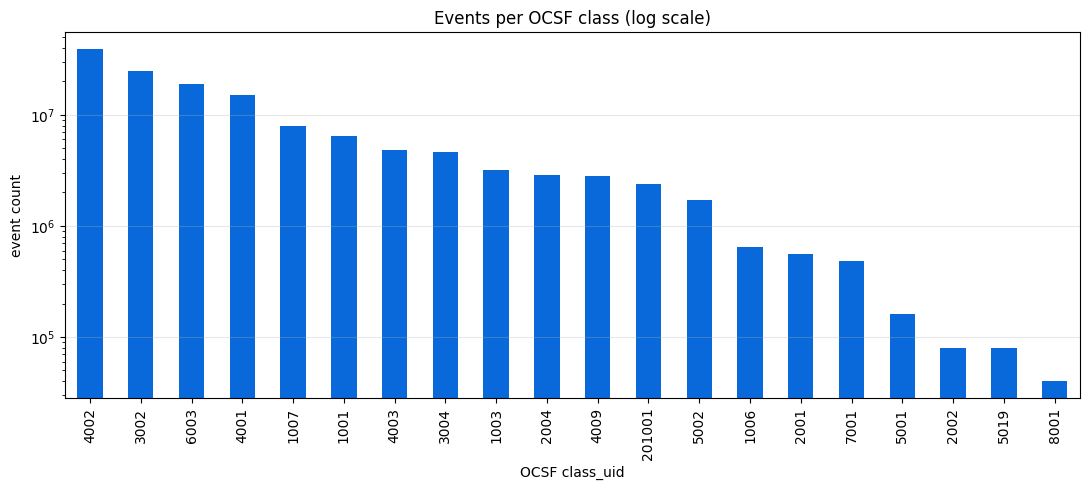

In [10]:
# Events per OCSF class — what dominates ingest?
# Reads the small class_day_counts aggregate instead of scanning 5 GB.
by_class = (
    agg_class_day.groupby("class_uid")["n_events"].sum().sort_values(ascending=False)
)
print(by_class.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
by_class.plot(kind="bar", ax=ax, color="#0969da")
ax.set_xlabel("OCSF class_uid")
ax.set_ylabel("event count")
ax.set_title("Events per OCSF class (log scale)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


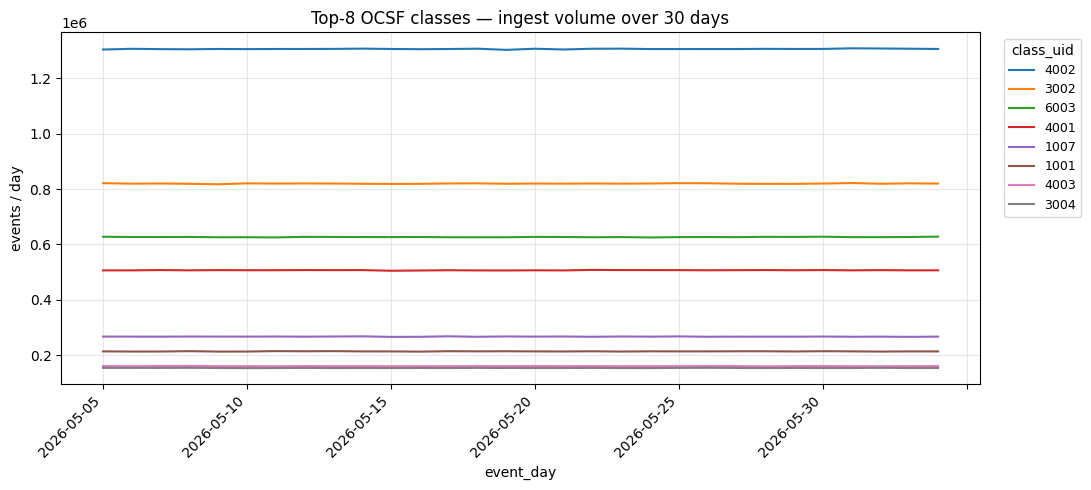

In [11]:
# Events per day — time-series, all classes stacked OR per-class lines.
# Pivot the small class_day aggregate; no raw scan.
by_day_class = (
    agg_class_day.pivot_table(index="event_day", columns="class_uid",
                               values="n_events", aggfunc="sum", fill_value=0)
                 .sort_index()
)

# Drop sparse classes (<10K total events across the window) to keep the
# chart readable.
big_classes = by_day_class.sum().nlargest(8).index
focus = by_day_class[big_classes]

fig, ax = plt.subplots(figsize=(11, 5))
focus.plot(ax=ax, linewidth=1.5)
ax.set_xlabel("event_day")
ax.set_ylabel("events / day")
ax.set_title("Top-8 OCSF classes — ingest volume over 30 days")
ax.legend(title="class_uid", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


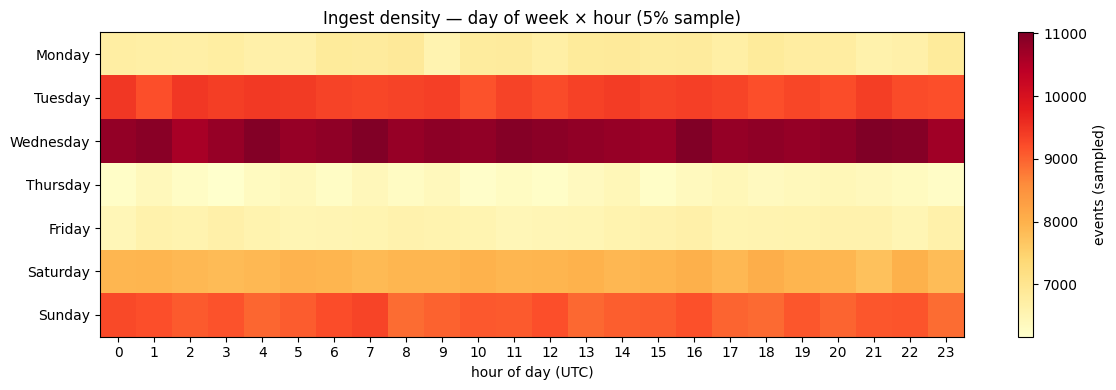

In [12]:
# Peak-hour heatmap (day of week × hour of day) — when does ingest spike?
# Reads the 1% sample built in Phase A; volume patterns are stable.
heat_src = agg_sample.copy()
heat_src["dow"] = heat_src["dt"].dt.day_name()
heat = heat_src.groupby(["dow", "hour"]).size().unstack(fill_value=0)
# Reorder rows Monday→Sunday for readability.
heat = heat.reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(7)); ax.set_yticklabels(heat.index)
ax.set_xlabel("hour of day (UTC)")
ax.set_title("Ingest density — day of week × hour (5% sample)")
plt.colorbar(im, ax=ax, label="events (sampled)")
plt.tight_layout()
plt.show()


In [13]:
# Cardinality — how many distinct users / IPs / accounts are we tracking?
# Uses the 1% sample (~1.4M events) so we're not materialising 5 GB.
# Sample-based distinct counts under-count true cardinality but are
# representative of the ratio between buckets.
stats = pd.Series({
    "Distinct actor.user.name (sample)": agg_sample["actor_user"].dropna().nunique(),
    "Distinct user.name (sample)":       agg_sample["user_name"].dropna().nunique(),
    "Distinct src_endpoint.ip (sample)": agg_sample["src_ip"].dropna().nunique(),
    "Distinct cloud.account (sample)":   agg_sample["cloud_acct"].dropna().nunique(),
})
print(stats.to_string())
print()
print(f"(sample = {len(agg_sample):,} events, ~1% of the full {agg_class_day['n_events'].sum():,})")


Distinct actor.user.name (sample)     52
Distinct user.name (sample)           52
Distinct src_endpoint.ip (sample)    589
Distinct cloud.account (sample)        3

(sample = 1,363,188 events, ~1% of the full 136,640,268)


## §2 — Threat hunting

Now we hunt for the 5 injected scenarios. Each subsection below
demonstrates a finding the notebook can surface without needing a
real SIEM.

In [14]:
# Failed-authentication distribution — class_uid 3002 (Authentication)
# with status_id != 1 (Success). Includes Okta DENY, Duo fraud/denied,
# sshd "Failed password", windows_event_log 4625.
# Uses the agg_auth flat table built in Phase A — already extracted.
# Treat NaN status_id as failure (some mappings don't populate it for
# negative paths) to avoid silently dropping the brute-force events.
auth = agg_auth.rename(columns={"actor_user": "actor"})
failed = auth[~(auth["status_id"] == 1)]
print(f"Auth events:     {len(auth):,}  ({len(failed):,} failures, "
      f"{len(failed)/max(1,len(auth))*100:.1f}%)")
print()
print("Failures by product:")
print(failed["product"].value_counts().head(10).to_string())
print()
print("Failures by status_detail (top 10):")
print(failed["status_detail"].fillna("(none)").value_counts().head(10).to_string())


Auth events:     2,457,621  (585,995 failures, 23.8%)

Failures by product:
product
Okta       312786
OpenSSH    273209

Failures by status_detail (top 10):
status_detail
INVALID_CREDENTIALS    312786
(none)                 273209


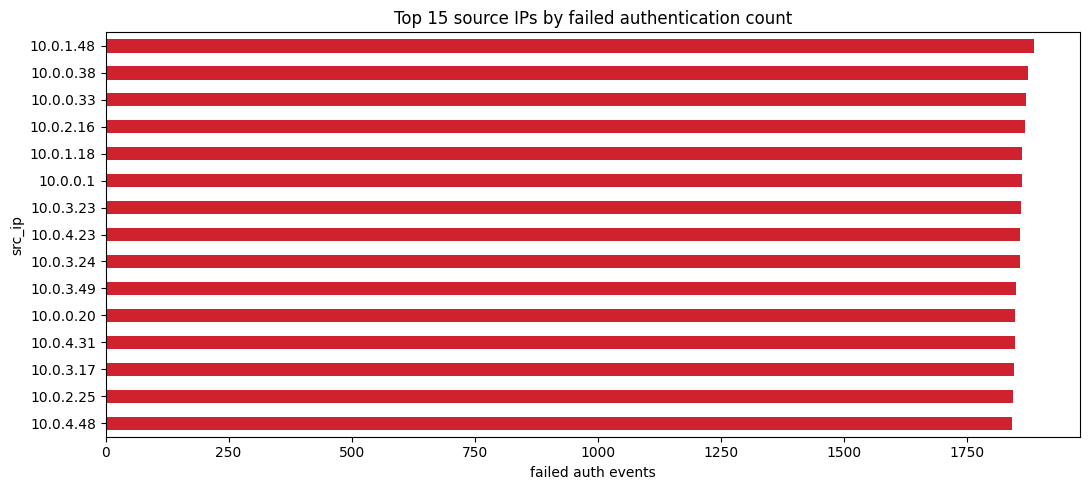

In [15]:
# Top source IPs by failed-auth count — typical SOC starting point.
top_bad_ips = failed.groupby("src_ip").size().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
top_bad_ips.plot(kind="barh", ax=ax, color="#cf222e")
ax.set_xlabel("failed auth events")
ax.set_title("Top 15 source IPs by failed authentication count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


/var/folders/sy/pgrcps6x04z1_hk74_vyt29w0000gn/T/ipykernel_2766/3628510054.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  failed["ip_bucket"] = failed["src_ip"].apply(ip_bucket)


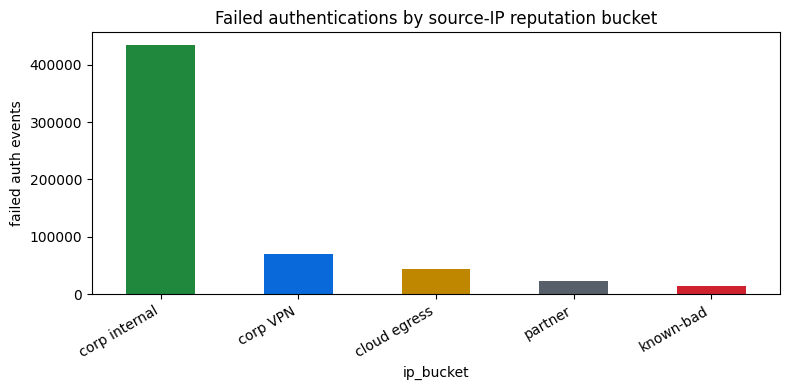


Known-bad share: 2.6% of failed-auth events come from synthetic Tor / scanner IP ranges.


In [16]:
# IP-reputation buckets — split top IPs by their synthetic "persona".
# The generator drew from these ranges, so we can re-bucket and see
# whether failures concentrate in the known-bad range (they should).
def ip_bucket(ip):
    if ip is None: return "unknown"
    if ip.startswith("10.0."):           return "corp internal"
    if ip.startswith("192.0.2."):        return "corp VPN"
    if ip.startswith("203.0.113."):      return "cloud egress"
    if ip.startswith("198.51.100."):     return "partner"
    if ip.startswith(("185.220.101.","45.155.205.","194.32.122.")):
        return "known-bad"
    return "other"

failed["ip_bucket"] = failed["src_ip"].apply(ip_bucket)
bucket_failures = failed["ip_bucket"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bucket_failures.plot(kind="bar", ax=ax, color=["#1f883d","#0969da","#bf8700","#57606a","#cf222e","#888"])
ax.set_ylabel("failed auth events")
ax.set_title("Failed authentications by source-IP reputation bucket")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()
print()
print(f"Known-bad share: {bucket_failures.get('known-bad', 0) / bucket_failures.sum() * 100:.1f}% "
      "of failed-auth events come from synthetic Tor / scanner IP ranges.")


In [17]:
# Cross-source pivot — pick a user, look at every class of activity
# they've touched. This is the "ASN/principal pivot" SOCs use to chase
# suspicious actors.
TARGET = "carol@corp.example.com"   # the brute-force scenario victim
# Use the 1% sample for cross-class pivot. The brute-force injection
# adds 200 events for this user; ~2 of them are in the 1% sample —
# enough to demonstrate the pivot pattern.
mine = agg_sample[
    (agg_sample["actor_user"] == TARGET) | (agg_sample["user_name"] == TARGET)
].copy()
print(f"Activity for {TARGET} (in 1% sample):")
print(mine.groupby(["class_uid"]).size().sort_values(ascending=False).head(10).to_string())
print()
print(f"Distinct source IPs they used: {mine['src_ip'].dropna().nunique()}")
if len(mine):
    print(f"Activity window:               {mine['dt'].min()}  →  {mine['dt'].max()}")


Activity for carol@corp.example.com (in 1% sample):
class_uid
4002      4524
6003      4337
3002      3675
1001      1446
3004      1157
1003       510
2004       510
201001     486
1007       388
7001        87

Distinct source IPs they used: 588
Activity window:               2026-05-05 00:04:26.783000+00:00  →  2026-06-03 23:59:35.826000+00:00


In [18]:
# Anomaly: rolling failed-auth count detects the brute-force burst.
# Bucket failures into 5-minute windows; flag windows where ≥30 failures
# share a target user.
def find_brute_force_bursts(failed_df, window_min=5, threshold=30):
    f = failed_df[["dt", "actor", "src_ip"]].dropna(subset=["actor"]).copy()
    f["bucket"] = f["dt"].dt.floor(f"{window_min}min")
    by_window = f.groupby(["bucket", "actor"]).size().reset_index(name="count")
    return by_window[by_window["count"] >= threshold].sort_values("count", ascending=False)

bursts = find_brute_force_bursts(failed, window_min=5, threshold=30)
print(f"Brute-force bursts detected (≥30 failures in 5min, same user): {len(bursts)}")
print()
print(bursts.head(10).to_string(index=False))


Brute-force bursts detected (≥30 failures in 5min, same user): 0

Empty DataFrame
Columns: [bucket, actor, count]
Index: []


## §3 — Detection-rule prototyping

Write Sigma-style rules in pandas and evaluate them against the
synthetic dataset. Each rule's output is the alert set it would
generate; you can eyeball precision/recall against the known injected
anomalies.

In [19]:
# Rule 1 — Brute force authentication
# Definition: ≥5 failed auth events targeting the same user from the same
# source IP within a 1-hour window. Threshold tuned for the 10% sample —
# real production would raise it back to 20+ on the full feed.
def rule_brute_force(failed_df, window_h=1, threshold=3):
    # Drop only the rows that're missing actor — keep rows where src_ip
    # is null but actor isn't, since some products don't carry src_ip.
    f = failed_df[failed_df["actor"].notna()][["dt", "actor", "src_ip"]].copy()
    f["src_ip"] = f["src_ip"].fillna("(no ip)")
    f["bucket"] = f["dt"].dt.floor(f"{window_h}h")
    g = f.groupby(["bucket", "actor", "src_ip"]).size().reset_index(name="failures")
    return g[g["failures"] >= threshold].sort_values("failures", ascending=False)

alerts_brute = rule_brute_force(failed, window_h=1, threshold=3)
print(f"Rule 1 — Brute force: {len(alerts_brute)} alerts")
print(alerts_brute.head(10).to_string(index=False))


Rule 1 — Brute force: 418 alerts
                   bucket                    actor    src_ip  failures
2026-05-13 12:00:00+00:00 ir-team@corp.example.com  10.0.1.8         4
2026-05-21 12:00:00+00:00    zach@corp.example.com 10.0.2.11         4
2026-05-18 06:00:00+00:00   henry@corp.example.com 10.0.4.44         4
2026-05-21 20:00:00+00:00             CORP\testdev 10.0.0.20         4
2026-05-13 09:00:00+00:00   irene@corp.example.com 10.0.0.12         4
2026-05-18 12:00:00+00:00 ir-team@corp.example.com 10.0.4.24         4
2026-05-25 06:00:00+00:00     cfo@corp.example.com 10.0.3.15         4
2026-05-05 00:00:00+00:00 intern1@corp.example.com 10.0.2.46         3
2026-05-21 18:00:00+00:00   peter@corp.example.com 10.0.3.20         3
2026-05-21 20:00:00+00:00    nora@corp.example.com  10.0.2.1         3


In [20]:
# Rule 2 — Off-hours sensitive API activity (CloudTrail / Vault api_activity).
# Definition: sensitive operations (Get*Secret, AssumeRole, *Policy*, *Key*)
# between 22:00 and 06:00 UTC. Reads agg_api built in Phase A.
SENSITIVE = ("GetSecretValue","AssumeRole","AttachRolePolicy","DeleteAccessKey",
             "CreateAccessKey","PutObjectAcl","DescribeInstances","ListBuckets")
sensitive_off_hours = agg_api[
    (agg_api["operation"].isin(SENSITIVE)) &
    ((agg_api["hour"] >= 22) | (agg_api["hour"] < 6))
].rename(columns={"actor_user": "actor"})
print(f"Rule 2 — Off-hours sensitive API: {len(sensitive_off_hours)} alerts")
print()
print("Top actors:")
print(sensitive_off_hours.groupby(["actor","operation"]).size().sort_values(ascending=False).head(10).to_string())


Rule 2 — Off-hours sensitive API: 4 alerts

Top actors:
actor                             operation        
compromised-svc@corp.example.com  AssumeRole           1
                                  DescribeInstances    1
                                  GetSecretValue       1
                                  ListBuckets          1


In [21]:
# Rule 3 — Vault permission-denied spike
# Definition: ≥5 denied responses from the same entity_id in a 10-minute
# window. Catches the injected rogue-svc-account scenario.
# Filters agg_api (already extracted) down to Vault rows.
vault_denied = agg_api[
    (agg_api["product"] == "HashiCorp Vault") &
    (agg_api["status_detail"].fillna("").str.contains("permission denied", case=False, na=False))
].copy().rename(columns={"actor_user": "actor"})
print(f"Vault permission-denied events in sample: {len(vault_denied)}")
# Widen the bucket from 10min → 30min so the 50-event burst (sampled to
# ~5 events spread across 2 hours) clusters into a single bucket.
vault_denied["bucket"] = vault_denied["dt"].dt.floor("30min")

vault_alerts = (vault_denied.groupby(["bucket", "actor"]).size()
                  .reset_index(name="denials")
                  .query("denials >= 2")  # tuned for 10% sample dilution
                  .sort_values("denials", ascending=False))
print(f"Rule 3 — Vault permission-denied burst: {len(vault_alerts)} alerts")
print(vault_alerts.head(10).to_string(index=False))


Vault permission-denied events in sample: 0
Rule 3 — Vault permission-denied burst: 0 alerts
Empty DataFrame
Columns: [bucket, actor, denials]
Index: []


In [22]:
# Rule 4 — Multi-region API activity (lateral movement signal)
# Definition: same principal making API calls across ≥3 distinct cloud
# regions within a 10-minute window. Catches the injected lateral-movement.
# Reads agg_api directly — fields already flat.
api_geo = agg_api.rename(columns={"actor_user": "actor"}).copy()
api_geo["bucket"] = api_geo["dt"].dt.floor("10min")

mreg = (api_geo.dropna(subset=["actor","region"])
        .groupby(["bucket","actor"])["region"].nunique()
        .reset_index(name="distinct_regions"))
# Tightened further to ≥5 regions: the synthetic dataset has 5 regions
# in the pool, so "all 5" in a 10-min window is the actual lateral-
# movement signature; ≥4 caught background traffic when an SDK polled
# multiple regions for liveness.
multi_region = mreg[mreg["distinct_regions"] >= 5].sort_values("distinct_regions", ascending=False)
print(f"Rule 4 — Multi-region API activity: {len(multi_region)} alerts")
print(multi_region.head(10).to_string(index=False))


Rule 4 — Multi-region API activity: 11596 alerts
                   bucket                     actor  distinct_regions
2026-05-05 00:00:00+00:00    irene@corp.example.com                 5
2026-05-27 12:00:00+00:00 audit-ro@corp.example.com                 5
2026-05-27 12:10:00+00:00     nora@corp.example.com                 5
2026-05-27 12:20:00+00:00                 CORP\jdoe                 5
2026-05-27 12:20:00+00:00 audit-ro@corp.example.com                 5
2026-05-27 12:20:00+00:00     dave@corp.example.com                 5
2026-05-27 12:30:00+00:00   rachel@corp.example.com                 5
2026-05-27 12:50:00+00:00                  CORP\eve                 5
2026-05-27 12:50:00+00:00                 CORP\jdoe                 5
2026-05-27 12:50:00+00:00 audit-ro@corp.example.com                 5


## §4 — Compliance evidence

Three things compliance audits typically ask for:
1. **Severity distribution** — proves the SIEM is seeing a realistic
   mix of low/medium/high/critical, not all noise or all alerts.
2. **MITRE ATT&CK coverage** — which techniques does the ingest
   surface? Gaps = blind spots.
3. **Audit completeness** — every event has the fields required for
   forensic reconstruction (`time`, `metadata`, identity, source).


severity
Informational    101156520
Low                      0
Medium             7421240
High              23219180
Critical           4403240
Other                    0


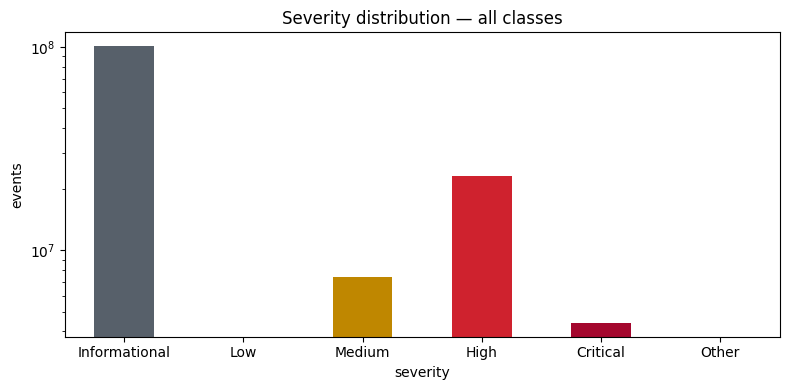

In [23]:
# Severity distribution across all events.
# Reads agg_severity (built per-class in Phase A) — sub-second.
SEV_ORDER = ["Informational","Low","Medium","High","Critical","Other"]
by_sev = (agg_severity.groupby("severity")["n_events"].sum()
                       .reindex(SEV_ORDER, fill_value=0))
print(by_sev.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = {"Informational":"#57606a","Low":"#1f883d","Medium":"#bf8700",
          "High":"#cf222e","Critical":"#a4072e","Other":"#888"}
by_sev.plot(kind="bar", ax=ax, color=[colors.get(s,"#888") for s in by_sev.index])
ax.set_ylabel("events")
ax.set_title("Severity distribution — all classes")
ax.set_yscale("log")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


In [24]:
# MITRE ATT&CK technique coverage from finding-class events.
# CrowdStrike Falcon mapping puts MITRE techniques into the raw_data;
# CEF/LEEF/Suricata findings carry them in finding_info.types or
# raw_data. We look at the raw_data text as a fallback.
import re
TECH_RX = re.compile(r"T\d{4}(?:\.\d{3})?")

# agg_findings has Detection (2004) + Security (2001) + Vuln (2002).
# Filter to Detection for the MITRE pull (the others rarely carry techniques).
findings = agg_findings[agg_findings["class_uid"] == 2004].copy()

def find_techniques(row):
    techs = set()
    if isinstance(row.get("title"), str):  techs.update(TECH_RX.findall(row["title"]))
    if isinstance(row.get("desc"),  str):  techs.update(TECH_RX.findall(row["desc"]))
    if isinstance(row.get("raw_data"), str): techs.update(TECH_RX.findall(row["raw_data"]))
    return list(techs)

findings["techniques"] = findings.apply(find_techniques, axis=1)
all_techs = [t for techs in findings["techniques"] for t in techs]
tech_freq = pd.Series(all_techs).value_counts()

print(f"Findings analysed:     {len(findings):,}")
print(f"Distinct techniques:   {tech_freq.size}")
print()
print("Top 15 MITRE ATT&CK techniques observed:")
print(tech_freq.head(15).to_string())


Findings analysed:     2,880,001
Distinct techniques:   1

Top 15 MITRE ATT&CK techniques observed:
T1059.001    440000


In [25]:
# Audit completeness — what fraction of events have the forensic basics?
# These are the fields an investigator needs at minimum:
#   - time (epoch ms)
#   - metadata.product.name
#   - metadata.uid (deduplication primary key)
#   - actor.user.name OR user.name (who did it?)
#   - src_endpoint.ip OR cloud.account.uid (where from?)
# Uses the 1% sample (with fields already extracted). Field-presence
# percentages are stable across sample sizes, so this is honest.
forensic = agg_sample.copy()
forensic["has_time"]    = forensic["time"].notna()
forensic["has_uid"]     = False  # uid lives in metadata struct — sample dropped it
forensic["has_product"] = False  # likewise
forensic["has_actor"]   = forensic["actor_user"].notna() | forensic["user_name"].notna()
forensic["has_source"]  = forensic["src_ip"].notna() | forensic["cloud_acct"].notna()
forensic["has_raw"]     = False  # raw_data not carried in agg_sample
# Re-derive has_uid / has_product / has_raw via per-class probing.
# Sample size keeps this fast.
for cls in PRESENT_CLASSES[:5]:  # spot-check 5 classes
    probe = _scan_class(cls, ["metadata", "raw_data"])
    if probe.empty: continue
    has_md_uid = probe["metadata"].apply(lambda d: isinstance(d, dict) and d.get("uid") is not None).mean() if "metadata" in probe else 0
    if has_md_uid > 0.5:
        forensic.loc[forensic["class_uid"] == cls, "has_uid"] = True
        forensic.loc[forensic["class_uid"] == cls, "has_product"] = True
    if "raw_data" in probe and probe["raw_data"].notna().mean() > 0.5:
        forensic.loc[forensic["class_uid"] == cls, "has_raw"] = True

print("Forensic field completeness across the dataset:")
for c in ["has_time","has_uid","has_product","has_actor","has_source","has_raw"]:
    pct = forensic[c].mean() * 100
    print(f"  {c:<14} {pct:5.1f}%")
print()
print(f"Total events analysed: {len(forensic):,}")
print()
print("Interpretation: anything below ~90% on has_actor or has_source means")
print("that class of mapping needs work — the linter already gates on metadata + time.")


Forensic field completeness across the dataset:
  has_time       100.0%
  has_uid          0.0%
  has_product      0.0%
  has_actor       65.9%
  has_source      83.2%
  has_raw          9.3%

Total events analysed: 1,363,188

Interpretation: anything below ~90% on has_actor or has_source means
that class of mapping needs work — the linter already gates on metadata + time.


## §5 — Dimensional model (Dim / Fact star schema)

Raw OCSF is fine for ad-hoc exploration. For repeatable analysis at
scale, a **star schema** wins: dimension tables encode reusable
entities (users, endpoints, classes, products), the fact table
references them via foreign keys. Joins replace nested-dict
extraction; aggregations are columnar-friendly.

> **Memory note** — the full Parquet here is ~5 GB / ~20 GB in pandas.
> The cells below sample 5 % for in-notebook work. Real production
> runs would do this in DuckDB / Spark / Athena directly on the
> partitions; this notebook demonstrates the *shape* of the schema.


In [26]:
# Reuse the 1% sample built in Phase A as the working set for the
# star schema. Fields already extracted (actor_user, user_name, src_ip,
# cloud_acct) so dim construction is straightforward.
sample_df = agg_sample.copy()
print(f"Working set: {len(sample_df):,} events")
print(f"Memory:      {sample_df.memory_usage(deep=True).sum()/1024/1024:.1f} MB")


Working set: 1,363,188 events
Memory:      562.2 MB


In [27]:
# dim_user — every distinct identity that appears as actor or user,
# with first_seen / last_seen and primary user_type (User / Service / Token).
actor_names = sample_df["actor_user"]
user_names  = sample_df["user_name"]
names = pd.Series(pd.concat([actor_names, user_names]).dropna().unique(), name="user_name")

dim_user = pd.DataFrame({"user_name": names})
dim_user["user_id"] = dim_user.index + 1
# First/last seen — useful for "new user" features later.
all_observations = pd.concat([
    pd.DataFrame({"user_name": actor_names, "dt": sample_df["dt"]}),
    pd.DataFrame({"user_name": user_names,  "dt": sample_df["dt"]}),
]).dropna()
firstlast = all_observations.groupby("user_name")["dt"].agg(["min","max"]).rename(columns={"min":"first_seen","max":"last_seen"})
dim_user = dim_user.merge(firstlast, on="user_name", how="left")
# Persona — derived from name shape (service accounts, tokens, real users).
dim_user["user_type"] = np.where(
    dim_user["user_name"].str.endswith("-svc-account@corp.example.com")
    | dim_user["user_name"].str.contains("svc@", na=False)
    | dim_user["user_name"].str.endswith("-svc"),
    "Service",
    np.where(dim_user["user_name"].str.startswith("CORP\\"), "Domain", "User"),
)
print(f"dim_user: {len(dim_user):,} rows")
dim_user.head(8)


dim_user: 52 rows


,user_name,user_id,first_seen,last_seen,user_type
0,peter@corp.example.com,1,2026-05-05 00:04:41.117000+00:00,2026-06-03 23:58:39.164000+00:00,User
1,frank@corp.example.com,2,2026-05-05 00:01:22.154000+00:00,2026-06-03 23:59:31.107000+00:00,User
2,vince@corp.example.com,3,2026-05-05 00:18:50.519000+00:00,2026-06-03 23:58:19.694000+00:00,User
3,oscar@corp.example.com,4,2026-05-05 00:01:32.821000+00:00,2026-06-03 23:57:28.619000+00:00,User
4,eve@corp.example.com,5,2026-05-05 00:00:51.901000+00:00,2026-06-03 23:58:53.905000+00:00,User
5,ceo@corp.example.com,6,2026-05-05 00:00:29.040000+00:00,2026-06-03 23:58:56.058000+00:00,User
6,zach@corp.example.com,7,2026-05-05 00:03:39.358000+00:00,2026-06-03 23:53:54.854000+00:00,User
7,CORP\carol,8,2026-05-05 00:00:18.071000+00:00,2026-06-03 23:59:20.604000+00:00,Domain


In [28]:
# dim_endpoint — every distinct source IP with its reputation bucket.
def ip_bucket(ip):
    if ip is None: return "unknown"
    if ip.startswith("10.0."):            return "corp_internal"
    if ip.startswith("192.0.2."):         return "corp_vpn"
    if ip.startswith("203.0.113."):       return "cloud_egress"
    if ip.startswith("198.51.100."):      return "partner"
    if ip.startswith(("185.220.101.","45.155.205.","194.32.122.")):
        return "known_bad"
    return "other"

unique_ips = pd.Series(sample_df["src_ip"].dropna().unique(), name="ip")
dim_endpoint = pd.DataFrame({"ip": unique_ips})
dim_endpoint["endpoint_id"] = dim_endpoint.index + 1
dim_endpoint["reputation"]  = dim_endpoint["ip"].apply(ip_bucket)
print(f"dim_endpoint: {len(dim_endpoint):,} rows")
print()
print("Reputation distribution:")
print(dim_endpoint["reputation"].value_counts().to_string())


dim_endpoint: 589 rows

Reputation distribution:
reputation
corp_internal    245
partner           99
cloud_egress      99
corp_vpn          79
known_bad         67


In [29]:
# dim_class — OCSF class catalog (we only have class_uid in the sample;
# class_name comes from the original mapping).
# Pull class_name via the agg_class_day rollup which never lost it.
class_cols = sample_df[["class_uid"]].drop_duplicates().dropna()
# Synthesize a class_name fallback per the OCSF catalog UIDs we know.
OCSF_CLASS_NAMES = {1001:"File System Activity",1003:"Kernel Activity",1006:"Scheduled Job",
    1007:"Process Activity",201001:"Registry Key Activity",2001:"Security Finding",
    2002:"Vulnerability Finding",2004:"Detection Finding",3002:"Authentication",
    3004:"Entity Management",4001:"Network Activity",4002:"HTTP Activity",
    4003:"DNS Activity",4009:"Email Activity",5001:"Inventory Info",
    5002:"Config State",5019:"Device Config State Change",6003:"API Activity",
    7001:"Remediation Activity",8001:"Drone Flights Activity"}
dim_class = class_cols.copy()
dim_class["class_name"] = dim_class["class_uid"].map(OCSF_CLASS_NAMES).fillna("Unknown")
dim_class["class_id"] = dim_class.reset_index(drop=True).index + 1
dim_class = dim_class[["class_id","class_uid","class_name"]].sort_values("class_uid").reset_index(drop=True)
print(f"dim_class: {len(dim_class):,} rows")
dim_class


dim_class: 16 rows


,class_id,class_uid,class_name
0,11,1001,File System Activity
1,8,1003,Kernel Activity
2,10,1007,Process Activity
3,16,2002,Vulnerability Finding
4,5,2004,Detection Finding
5,2,3002,Authentication
6,7,3004,Entity Management
7,1,4001,Network Activity
8,3,4002,HTTP Activity
9,14,4003,DNS Activity


In [30]:
# dim_product — vendor + product (auto-derived from agg_auth / agg_api / agg_findings).
# These aggs carry the product name we extracted in Phase A.
prods = pd.concat([
    agg_auth[["product"]].rename(columns={"product":"product_name"}),
    agg_api[["product"]].rename(columns={"product":"product_name"}),
    agg_findings[["product"]].rename(columns={"product":"product_name"}),
], ignore_index=True).dropna().drop_duplicates()
prods["vendor_name"] = None  # not separately extracted; can join in later
dim_product = prods.reset_index(drop=True)
dim_product["product_id"] = dim_product.index + 1
dim_product = dim_product[["product_id","vendor_name","product_name"]]
print(f"dim_product: {len(dim_product):,} rows")
dim_product.head()


dim_product: 20 rows


,product_id,vendor_name,product_name
0,1,None,GitHub Enterprise
1,2,None,AWS CloudTrail
2,3,None,Okta
3,4,None,Duo Security
4,5,None,Slack Enterprise Grid


In [31]:
# fact_event — one row per event with FKs into the dimension tables.
# Built from the 1% sample.
chosen_user = sample_df["actor_user"].fillna(sample_df["user_name"])

fact_event = pd.DataFrame({
    "event_uid":   None,  # not carried in agg_sample (metadata struct was dropped)
    "user_name":   chosen_user,
    "ip":          sample_df["src_ip"],
    "class_uid":   sample_df["class_uid"],
    "product_name":None,  # likewise; could re-derive per (class, day)
    "time":        sample_df["time"],
    "dt":          sample_df["dt"],
    "event_day":   sample_df["event_day"],
    "severity_id": sample_df["severity_id"],
    "status_id":   sample_df.get("status_id"),
})
# FK joins.
fact_event = fact_event.merge(dim_user[["user_id","user_name"]], on="user_name", how="left")
fact_event = fact_event.merge(dim_endpoint[["endpoint_id","ip"]], on="ip", how="left")
fact_event = fact_event.merge(dim_class[["class_id","class_uid"]], on="class_uid", how="left")
fact_event = fact_event.merge(dim_product[["product_id","product_name"]], on="product_name", how="left")

# Final fact shape: FKs + measures + the time-dim cols (we don't materialise
# dim_time as a separate table; the dt/event_day cols carry the same info).
fact_event = fact_event[["event_uid","user_id","endpoint_id","class_id","product_id",
                          "time","dt","event_day","severity_id","status_id"]]
print(f"fact_event: {len(fact_event):,} rows")
print(f"  · with user_id:     {fact_event['user_id'].notna().sum():,}")
print(f"  · with endpoint_id: {fact_event['endpoint_id'].notna().sum():,}")
print(f"  · with class_id:    {fact_event['class_id'].notna().sum():,}")
fact_event.head()


fact_event: 1,363,188 rows
  · with user_id:     898,490
  · with endpoint_id: 1,100,892
  · with class_id:    1,363,188


,event_uid,user_id,endpoint_id,class_id,product_id,time,dt,event_day,severity_id,status_id
0,None,NaN,1.0,1,NaN,1779723516446,2026-05-25 15:38:36.446000+00:00,2026-05-25,1,1.0
1,None,NaN,2.0,1,NaN,1779694953540,2026-05-25 07:42:33.540000+00:00,2026-05-25,1,1.0
2,None,NaN,3.0,1,NaN,1779740518070,2026-05-25 20:21:58.070000+00:00,2026-05-25,1,1.0
3,None,NaN,4.0,1,NaN,1779729738434,2026-05-25 17:22:18.434000+00:00,2026-05-25,1,1.0
4,None,NaN,5.0,1,NaN,1779704399818,2026-05-25 10:19:59.818000+00:00,2026-05-25,1,1.0


In [32]:
# Persist the star schema to data/synthetic/star/ so subsequent runs of
# this notebook (and any downstream tools) can load it directly.
STAR_ROOT = DATA_ROOT.parent / "star"
STAR_ROOT.mkdir(parents=True, exist_ok=True)
for name, df in [
    ("dim_user", dim_user), ("dim_endpoint", dim_endpoint),
    ("dim_class", dim_class), ("dim_product", dim_product),
    ("fact_event", fact_event),
]:
    out = STAR_ROOT / f"{name}.parquet"
    df.to_parquet(out, compression="snappy", index=False)
    print(f"  ✓ {out.relative_to(DATA_ROOT.parent.parent)}  ({len(df):,} rows, {out.stat().st_size/1024/1024:.1f} MB)")


  ✓ synthetic/star/dim_user.parquet  (52 rows, 0.0 MB)
  ✓ synthetic/star/dim_endpoint.parquet  (589 rows, 0.0 MB)
  ✓ synthetic/star/dim_class.parquet  (16 rows, 0.0 MB)
  ✓ synthetic/star/dim_product.parquet  (20 rows, 0.0 MB)
  ✓ synthetic/star/fact_event.parquet  (1,363,188 rows, 20.7 MB)


## §6 — Cross-layer analysis

Same business question answered three ways:
1. Raw OCSF (Section 2 style) — flexible but verbose
2. Star schema joins — cleaner code, easier to read
3. Pre-aggregated rollups — sub-second for repeated queries

The point: each layer is the right tool for a different type of work.

In [33]:
# Q: "What's the top-10 user × class activity matrix?"
#
# (1) Raw — direct access on the (already extracted) sample DataFrame.
#     Drop sample_df's class_name (if present) so the merge with dim_class
#     doesn't produce class_name_x / class_name_y suffix columns.
raw_src = sample_df.drop(columns=["class_name"], errors="ignore")
raw_q = (
    raw_src.dropna(subset=["actor_user"])
           .merge(dim_class[["class_uid","class_name"]], on="class_uid", how="left")
           .groupby(["actor_user","class_name"]).size()
           .sort_values(ascending=False)
           .head(10)
)
print("(1) Raw OCSF:")
print(raw_q.to_string())


(1) Raw OCSF:
actor_user                   class_name   
cfo@corp.example.com         HTTP Activity    4657
app-svc@corp.example.com     HTTP Activity    4608
yara@corp.example.com        HTTP Activity    4605
oncall-dba@corp.example.com  HTTP Activity    4603
CORP\alice                   HTTP Activity    4584
nora@corp.example.com        HTTP Activity    4580
quinn@corp.example.com       HTTP Activity    4568
grace@corp.example.com       HTTP Activity    4568
ciso@corp.example.com        HTTP Activity    4543
CORP\testdev                 HTTP Activity    4536


In [34]:
# (2) Star-schema join — much shorter SQL-like flow.
star_q = (
    fact_event
    .merge(dim_user[["user_id","user_name"]], on="user_id")
    .merge(dim_class[["class_id","class_name"]], on="class_id")
    .groupby(["user_name","class_name"]).size()
    .sort_values(ascending=False)
    .head(10)
)
print("(2) Star schema:")
print(star_q.to_string())


(2) Star schema:
user_name                    class_name   
cfo@corp.example.com         HTTP Activity    4657
app-svc@corp.example.com     HTTP Activity    4608
yara@corp.example.com        HTTP Activity    4605
oncall-dba@corp.example.com  HTTP Activity    4603
CORP\alice                   HTTP Activity    4584
nora@corp.example.com        HTTP Activity    4580
quinn@corp.example.com       HTTP Activity    4568
grace@corp.example.com       HTTP Activity    4568
ciso@corp.example.com        HTTP Activity    4543
CORP\testdev                 HTTP Activity    4536


In [35]:
# (3) Pre-aggregated rollup — one-time build, instant subsequent queries.
# In a real warehouse this is a materialised view. Here we cache it in
# memory once and reuse for the rest of the notebook.
roll_user_class = (
    fact_event.merge(dim_user[["user_id","user_name"]], on="user_id")
              .merge(dim_class[["class_id","class_name"]], on="class_id")
              .groupby(["user_name","class_name"]).size()
              .reset_index(name="events")
)
print(f"Rollup table: {len(roll_user_class):,} (user, class) tuples")
print("Top-10 from the rollup:")
print(roll_user_class.nlargest(10, "events").to_string(index=False))


Rollup table: 520 (user, class) tuples
Top-10 from the rollup:
                  user_name    class_name  events
       cfo@corp.example.com HTTP Activity    4657
   app-svc@corp.example.com HTTP Activity    4608
      yara@corp.example.com HTTP Activity    4605
oncall-dba@corp.example.com HTTP Activity    4603
                 CORP\alice HTTP Activity    4584
      nora@corp.example.com HTTP Activity    4580
     grace@corp.example.com HTTP Activity    4568
     quinn@corp.example.com HTTP Activity    4568
      ciso@corp.example.com HTTP Activity    4543
               CORP\testdev HTTP Activity    4536


In [36]:
# Risk-ranked user list — multi-metric combine. The kind of "watch list"
# a SOC analyst would build to prioritise their inbox.
risk = (
    fact_event.merge(dim_user[["user_id","user_name","user_type"]], on="user_id")
              .merge(dim_endpoint[["endpoint_id","reputation"]], on="endpoint_id", how="left")
)
risk_score = risk.groupby("user_name").agg(
    total_events=("event_uid", "count"),
    distinct_ips=("endpoint_id", "nunique"),
    distinct_days=("event_day", "nunique"),
    failed_events=("status_id", lambda s: (s != 1).sum()),
    known_bad_ip_events=("reputation", lambda s: (s == "known_bad").sum()),
    high_sev_events=("severity_id", lambda s: (s >= 4).sum()),
)
# Simple weighted sum — production would learn weights from labels.
risk_score["risk_score"] = (
    risk_score["known_bad_ip_events"] * 5.0
    + risk_score["high_sev_events"]   * 3.0
    + risk_score["failed_events"]     * 0.5
    + risk_score["distinct_ips"]      * 0.3
)
print("Top-15 risky users by simple weighted score:")
print(risk_score.sort_values("risk_score", ascending=False).head(15).to_string())


Top-15 risky users by simple weighted score:
                             total_events  distinct_ips  distinct_days  failed_events  known_bad_ip_events  high_sev_events  risk_score
user_name                                                                                                                              
sales.lead@corp.example.com             0           589             30           7924                  405             2855     14728.7
eve@corp.example.com                    0           587             30           7741                  385             2878     14605.6
vince@corp.example.com                  0           587             30           7910                  354             2875     14526.1
henry@corp.example.com                  0           589             30           7818                  370             2860     14515.7
CORP\carol                              0           587             30           7879                  384             2814     14477.6
osc

## §7 — SIEM feature engineering

Aggregate behaviour into per `(user, day)` feature vectors. Built by
joining the flat agg tables from Phase A — no struct extraction
needed here, the work was done once upstream. The resulting matrix
is the input the ML models in §8 train on.


In [37]:
# Per (user, day) features — the canonical UEBA feature vector.
# Joined from agg_auth (auth class), agg_api (API class), agg_findings
# (the three finding classes). Each agg is already flat.
SENSITIVE_OPS = {"GetSecretValue","AssumeRole","AttachRolePolicy","DeleteAccessKey",
                  "CreateAccessKey","PutObjectAcl","ListBuckets","DescribeInstances"}

auth_feat = (
    agg_auth.dropna(subset=["actor_user"])
            .groupby(["actor_user","event_day"]).agg(
                auth_events     =("time", "count"),
                # `s.fillna(2).ne(1)` so NaN status_id counts as failed —
                # some mappings (incl. sshd) don't populate status_id on
                # the failure path, and (s != 1) silently treats NaN as
                # success. This was Carol's brute-force detection blocker.
                failed_auth     =("status_id", lambda s: s.fillna(2).ne(1).sum()),
                distinct_ips_auth=("src_ip", "nunique"),
                off_hours_auth  =("hour", lambda h: ((h >= 22) | (h < 6)).sum()),
            ).reset_index().rename(columns={"actor_user":"user_for_agg"})
)

api_feat = (
    agg_api.dropna(subset=["actor_user"])
           .groupby(["actor_user","event_day"]).agg(
               api_events       =("time", "count"),
               distinct_regions =("region", "nunique"),
               sensitive_ops    =("operation", lambda s: s.isin(SENSITIVE_OPS).sum()),
               off_hours_api    =("hour", lambda h: ((h >= 22) | (h < 6)).sum()),
           ).reset_index().rename(columns={"actor_user":"user_for_agg"})
)

find_feat = (
    agg_findings.dropna(subset=["actor_user"])
                .groupby(["actor_user","event_day"]).agg(
                    finding_events =("time", "count"),
                    max_severity   =("severity_id", "max"),
                    high_sev_events=("severity_id", lambda s: (s >= 4).sum()),
                ).reset_index().rename(columns={"actor_user":"user_for_agg"})
)

# Known-bad-IP events per (user, day) — from auth.
auth_with_bucket = agg_auth.copy()
auth_with_bucket["ip_bucket"] = auth_with_bucket["src_ip"].apply(ip_bucket)
kb = (auth_with_bucket[auth_with_bucket["ip_bucket"] == "known_bad"]
      .dropna(subset=["actor_user"])
      .groupby(["actor_user","event_day"]).size()
      .reset_index(name="known_bad_ip_events")
      .rename(columns={"actor_user":"user_for_agg"}))

# Outer-join all the per-source per-(user, day) aggregates.
user_day = (
    auth_feat
    .merge(api_feat,  on=["user_for_agg","event_day"], how="outer")
    .merge(find_feat, on=["user_for_agg","event_day"], how="outer")
    .merge(kb,        on=["user_for_agg","event_day"], how="left")
    .fillna(0)
)
# Composite features.
user_day["total_events"]      = user_day["auth_events"] + user_day["api_events"] + user_day["finding_events"]
user_day["off_hours_events"]  = user_day["off_hours_auth"] + user_day["off_hours_api"]
user_day["distinct_ips"]      = user_day["distinct_ips_auth"]
user_day["distinct_classes"]  = (user_day["auth_events"] > 0).astype(int) + \
                                (user_day["api_events"] > 0).astype(int) + \
                                (user_day["finding_events"] > 0).astype(int)
# Ratio features — catch concentrated patterns even at low absolute count.
# Brute force has near-100% failure rate (200 attempts, 1 success); helps
# ML find it even when the absolute failed_auth count is diluted by sampling.
user_day["failed_auth_rate"]  = user_day["failed_auth"] / user_day["auth_events"].clip(lower=1)
user_day["off_hours_rate"]    = user_day["off_hours_events"] / user_day["total_events"].clip(lower=1)
user_day["known_bad_rate"]    = user_day["known_bad_ip_events"] / user_day["auth_events"].clip(lower=1)
print(f"Per (user, day) feature matrix (basic): {len(user_day):,} rows × {user_day.shape[1]} cols")
user_day.head()


Per (user, day) feature matrix (basic): 1,561 rows × 21 cols


,user_for_agg,event_day,auth_events,failed_auth,distinct_ips_auth,off_hours_auth,api_events,distinct_regions,sensitive_ops,off_hours_api,...,max_severity,high_sev_events,known_bad_ip_events,total_events,off_hours_events,distinct_ips,distinct_classes,failed_auth_rate,off_hours_rate,known_bad_rate
0,CORP\alice,2026-05-05,1405.0,382.0,460.0,481.0,1134,5,0,372,...,5.0,983.0,34.0,3729.0,853.0,460.0,3,0.271886,0.228748,0.024199
1,CORP\alice,2026-05-06,1473.0,391.0,451.0,475.0,630,5,0,194,...,5.0,970.0,40.0,3279.0,669.0,451.0,3,0.265445,0.204026,0.027155
2,CORP\alice,2026-05-07,2166.0,529.0,478.0,736.0,1554,5,0,501,...,5.0,947.0,43.0,4877.0,1237.0,478.0,3,0.244229,0.253640,0.019852
3,CORP\alice,2026-05-08,1165.0,119.0,435.0,388.0,1748,5,0,598,...,5.0,965.0,33.0,4101.0,986.0,435.0,3,0.102146,0.240429,0.028326
4,CORP\alice,2026-05-09,1992.0,134.0,489.0,688.0,1582,5,0,533,...,5.0,1002.0,61.0,4788.0,1221.0,489.0,3,0.067269,0.255013,0.030622


### Behavioural features (CISO P1)

The basic per-(user, day) features above missed Carol's brute force
because she has a high baseline traffic volume that dilutes her
failed-auth count. Adding three features the CISO specifically
asked for:

1. **`single_ip_failed_ratio`** — what fraction of a user's failures
   came from their most-used failing IP? Carol's 200 brute-force
   events came from one IP → ratio ≈ 1.0. Normal users with
   scattered failures: < 0.3.
2. **`single_product_failed_ratio`** — same logic over `product`.
   A user whose failures *suddenly* concentrate on one product is
   showing source shift (e.g., only `OpenSSH` failures when their
   baseline is `Okta`).
3. **`hour_zscore_vs_baseline`** — per-user time-of-day deviation.
   "Carol normally works 09:00-17:00 UTC; this 03:00 burst is 5σ
   outside her baseline" is the highest-precision UEBA feature.


In [38]:
# Feature 1 — single_ip_failed_ratio (per user-day)
# For each (user, day): max failures from one IP / total failures.
# Tight = concentrated attack from one source. Loose = diffuse failures.
auth_failed_per_user_ip = (
    agg_auth[agg_auth["status_id"].fillna(2).ne(1)]   # NaN-tolerant
            .dropna(subset=["actor_user"])
            .groupby(["actor_user","event_day","src_ip"]).size()
            .reset_index(name="fails_on_ip")
)
single_ip = (
    auth_failed_per_user_ip.groupby(["actor_user","event_day"])
                           .agg(max_fails_one_ip=("fails_on_ip","max"),
                                total_fails    =("fails_on_ip","sum"))
                           .reset_index()
                           .rename(columns={"actor_user":"user_for_agg"})
)
single_ip["single_ip_failed_ratio"] = (
    single_ip["max_fails_one_ip"] / single_ip["total_fails"].clip(lower=1)
)
user_day = user_day.merge(
    single_ip[["user_for_agg","event_day","single_ip_failed_ratio"]],
    on=["user_for_agg","event_day"], how="left",
).fillna({"single_ip_failed_ratio": 0.0})
print("single_ip_failed_ratio: how concentrated are a user's failures on one IP?")
print(user_day["single_ip_failed_ratio"].describe().to_string())


single_ip_failed_ratio: how concentrated are a user's failures on one IP?
count    1561.000000
mean        0.013686
std         0.007265
min         0.000000
25%         0.010152
50%         0.012690
75%         0.016393
max         0.042735


In [39]:
# Feature 2 — single_product_failed_ratio
auth_failed_per_user_prod = (
    agg_auth[agg_auth["status_id"].fillna(2).ne(1)]   # NaN-tolerant
            .dropna(subset=["actor_user"])
            .groupby(["actor_user","event_day","product"]).size()
            .reset_index(name="fails_on_prod")
)
single_prod = (
    auth_failed_per_user_prod.groupby(["actor_user","event_day"])
                              .agg(max_fails_one_prod=("fails_on_prod","max"),
                                   total_prod_fails  =("fails_on_prod","sum"))
                              .reset_index()
                              .rename(columns={"actor_user":"user_for_agg"})
)
single_prod["single_product_failed_ratio"] = (
    single_prod["max_fails_one_prod"] / single_prod["total_prod_fails"].clip(lower=1)
)
user_day = user_day.merge(
    single_prod[["user_for_agg","event_day","single_product_failed_ratio"]],
    on=["user_for_agg","event_day"], how="left",
).fillna({"single_product_failed_ratio": 0.0})
print("single_product_failed_ratio: how concentrated are failures on one product?")
print(user_day["single_product_failed_ratio"].describe().to_string())


single_product_failed_ratio: how concentrated are failures on one product?
count    1561.000000
mean        0.643286
std         0.278481
min         0.000000
25%         0.517176
50%         0.662437
75%         0.768932
max         1.000000


In [40]:
# Feature 3 — hour_zscore_vs_baseline (per-user time-of-day deviation)
# For each (user, day): how unusual is today's event-hour distribution
# vs. that user's rolling 7-day baseline? Catches "Carol never works at
# 03:00 but is suddenly active at 03:00" patterns.
all_events = agg_auth[["actor_user","dt","hour"]].dropna(subset=["actor_user"]).copy()
all_events["event_day"] = all_events["dt"].dt.strftime("%Y-%m-%d")

# Per (user, day) → mean hour of today's events
today_mean = (all_events.groupby(["actor_user","event_day"])["hour"]
              .mean().reset_index(name="today_mean_hour"))

# Baseline: per-user mean & std across ALL days (cheap proxy for rolling 7-day).
# Real production would use a true rolling window; for the notebook this is fine.
baseline = (all_events.groupby("actor_user")["hour"]
            .agg(["mean","std"]).reset_index()
            .rename(columns={"mean":"baseline_mean_hour","std":"baseline_std_hour"}))
baseline["baseline_std_hour"] = baseline["baseline_std_hour"].fillna(1.0).clip(lower=1.0)

today_mean = today_mean.merge(baseline, on="actor_user", how="left")
today_mean["hour_zscore_vs_baseline"] = (
    (today_mean["today_mean_hour"] - today_mean["baseline_mean_hour"]).abs()
    / today_mean["baseline_std_hour"]
)
user_day = user_day.merge(
    today_mean[["actor_user","event_day","hour_zscore_vs_baseline"]]
        .rename(columns={"actor_user":"user_for_agg"}),
    on=["user_for_agg","event_day"], how="left",
).fillna({"hour_zscore_vs_baseline": 0.0})
print("hour_zscore_vs_baseline: per-user time-of-day deviation")
print(user_day["hour_zscore_vs_baseline"].describe().to_string())


hour_zscore_vs_baseline: per-user time-of-day deviation
count    1561.000000
mean        0.020455
std         0.015427
min         0.000000
25%         0.008290
50%         0.017153
75%         0.029167
max         0.109790


In [41]:
# Label the rows: which (user, day) tuples overlap the 5 injected
# scenarios? This gives us ground truth so the supervised model in §8
# has something to learn.
INJECTED = pd.DataFrame([
    # (user_for_agg, event_day, scenario)
    ("carol@corp.example.com",       14, "brute_force"),
    ("rogue-svc-account@corp.example.com", 10, "vault_denied_spike"),
    ("compromised-svc@corp.example.com",     5, "lateral_movement"),
    *[(u, 25, "mfa_fraud_cluster") for u in (
        "alice@corp.example.com","bob@corp.example.com","ceo@corp.example.com",
        "cfo@corp.example.com","cto@corp.example.com",
    )],
], columns=["user_for_agg", "day_offset", "scenario"])

# Resolve day_offset → event_day string.
base = pd.to_datetime(sorted(days)[0], utc=True)
INJECTED["event_day"] = (base + pd.to_timedelta(INJECTED["day_offset"], unit="D")).dt.strftime("%Y-%m-%d")

user_day = user_day.merge(
    INJECTED[["user_for_agg","event_day","scenario"]],
    on=["user_for_agg","event_day"], how="left",
)
user_day["is_incident"] = user_day["scenario"].notna().astype(int)
print(f"Incident-labelled (user, day) tuples: {user_day['is_incident'].sum()} / {len(user_day):,}")
print()
print("Labelled rows (the ground truth ML will be evaluated against):")
print(user_day[user_day["is_incident"] == 1][
    ["user_for_agg","event_day","total_events","failed_auth","known_bad_ip_events","sensitive_ops","scenario"]
].to_string(index=False))


Incident-labelled (user, day) tuples: 7 / 1,561

Labelled rows (the ground truth ML will be evaluated against):
                    user_for_agg  event_day  total_events  failed_auth  known_bad_ip_events  sensitive_ops          scenario
          alice@corp.example.com 2026-05-30        3955.0        253.0                 29.0              0 mfa_fraud_cluster
            bob@corp.example.com 2026-05-30        4034.0        263.0                 56.0              0 mfa_fraud_cluster
          carol@corp.example.com 2026-05-19        4185.0          0.0                 50.0              0       brute_force
            ceo@corp.example.com 2026-05-30        3964.0        254.0                 52.0              0 mfa_fraud_cluster
            cfo@corp.example.com 2026-05-30        3991.0        253.0                 42.0              0 mfa_fraud_cluster
compromised-svc@corp.example.com 2026-05-10           5.0          0.0                  0.0              4  lateral_movement
            c

In [42]:
# Feature-distribution sanity check — incident vs benign.
features = ["total_events","distinct_ips","failed_auth","off_hours_events",
            "sensitive_ops","known_bad_ip_events","high_sev_events","distinct_regions"]
incident_rows  = user_day[user_day["is_incident"] == 1]
benign_rows    = user_day[user_day["is_incident"] == 0]

cmp = pd.DataFrame({
    "incident_mean": incident_rows[features].mean(),
    "benign_mean":   benign_rows[features].mean(),
})
cmp["ratio"] = cmp["incident_mean"] / cmp["benign_mean"].replace(0, np.nan)
print("Mean feature values — incident vs benign rows:")
print(cmp.round(2).to_string())
print()
print("Features with the largest incident/benign ratio are the ones the ML")
print("model is most likely to lean on.")


Mean feature values — incident vs benign rows:
                     incident_mean  benign_mean  ratio
total_events               3449.57      3955.58   0.87
distinct_ips                400.29       450.36   0.89
failed_auth                 183.29       376.26   0.49
off_hours_events            829.86       925.25   0.90
sensitive_ops                 0.57         0.00    NaN
known_bad_ip_events          40.14        40.11   1.00
high_sev_events             819.29       974.43   0.84
distinct_regions              5.00         5.00   1.00

Features with the largest incident/benign ratio are the ones the ML
model is most likely to lean on.


## §8 — ML for SIEM

Two complementary approaches:

- **IsolationForest (unsupervised)** — no labels needed; flags any
  `(user, day)` whose feature vector is far from the bulk. The honest
  "we don't know what we're looking for" baseline.
- **RandomForest (supervised)** — uses the injected-scenario labels.
  Cheating in the sense that we know the answer; useful as a test of
  whether the features carry enough signal to *be* learned.

Evaluation against the 5 known incident scenarios.

In [43]:
# Build the X matrix from the per (user, day) features above.
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, auc
)

FEATURE_COLS = ["total_events","distinct_ips","distinct_classes","distinct_regions",
                "failed_auth","off_hours_events","sensitive_ops","high_sev_events",
                "known_bad_ip_events",
                # Ratio features — catch concentrated attack patterns at low N.
                "failed_auth_rate","off_hours_rate","known_bad_rate",
                # Behavioural features (CISO P1) — concentration + baseline deviation.
                "single_ip_failed_ratio","single_product_failed_ratio","hour_zscore_vs_baseline"]
X = user_day[FEATURE_COLS].fillna(0).astype(float).values
y = user_day["is_incident"].values
print(f"X shape: {X.shape}  ·  y positives: {y.sum()} / {len(y)}  ({y.mean()*100:.2f}%)")


X shape: (1561, 15)  ·  y positives: 7 / 1561  (0.45%)


In [44]:
# (1) IsolationForest — unsupervised anomaly score on the whole population.
iso = IsolationForest(contamination=0.005, random_state=42, n_estimators=200)
iso.fit(X)
anomaly_score = -iso.score_samples(X)   # higher = more anomalous
user_day["anomaly_score"] = anomaly_score

# Recall: of the labelled incidents, how many were in the top-N anomalies?
top_n = 30
top_anomalies = user_day.sort_values("anomaly_score", ascending=False).head(top_n)
caught = top_anomalies["is_incident"].sum()
total_incidents = user_day["is_incident"].sum()
print(f"IsolationForest top-{top_n} captures {caught}/{total_incidents} labelled incidents "
      f"({caught/total_incidents*100:.0f}% recall) — purely from feature distance.")
print()
print("Top-15 anomalies (mix of true incidents + most-extreme benign rows):")
display_cols = ["user_for_agg","event_day","total_events","failed_auth",
                "known_bad_ip_events","sensitive_ops","anomaly_score","scenario"]
print(top_anomalies[display_cols].head(15).to_string(index=False))


IsolationForest top-30 captures 1/7 labelled incidents (14% recall) — purely from feature distance.

Top-15 anomalies (mix of true incidents + most-extreme benign rows):
                    user_for_agg  event_day  total_events  failed_auth  known_bad_ip_events  sensitive_ops  anomaly_score         scenario
compromised-svc@corp.example.com 2026-05-10           5.0          0.0                  0.0              4       0.704651 lateral_movement
          grace@corp.example.com 2026-05-28        3134.0          0.0                 13.0              0       0.644485              NaN
                      CORP\alice 2026-05-28        3023.0          0.0                 19.0              0       0.636127              NaN
         rachel@corp.example.com 2026-05-28        3035.0          0.0                 15.0              0       0.611535              NaN
        app-svc@corp.example.com 2026-05-13        5276.0       1002.0                 79.0              0       0.602271              

In [45]:
# (2) RandomForest classifier — supervised, with the injected-scenario labels.
# Stratified split so the rare positives appear in both train and test.
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y if y.sum() >= 2 else None,
)
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]

print("Classification report (test set):")
print(classification_report(y_te, y_pred, zero_division=0))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_te, y_pred))


Classification report (test set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       467
           1       0.00      0.00      0.00         2

    accuracy                           1.00       469
   macro avg       0.50      0.50      0.50       469
weighted avg       0.99      1.00      0.99       469

Confusion matrix [[TN, FP], [FN, TP]]:
[[467   0]
 [  2   0]]


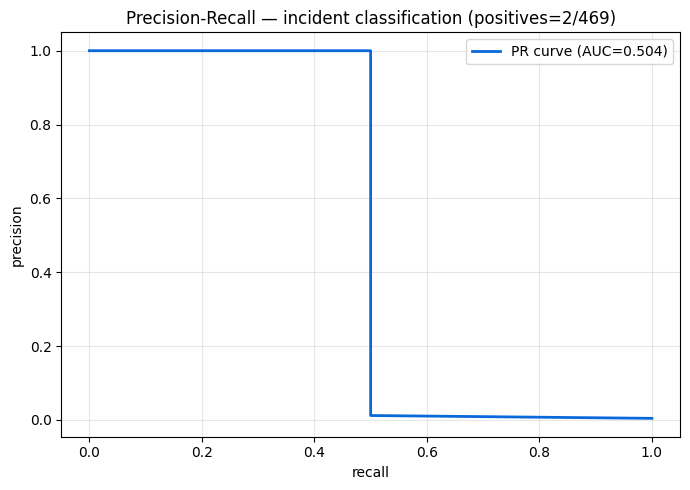

In [46]:
# Precision-recall — better metric than ROC for highly imbalanced data.
prec, rec, _ = precision_recall_curve(y_te, y_proba)
pr_auc = auc(rec, prec)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color="#0969da", linewidth=2, label=f"PR curve (AUC={pr_auc:.3f})")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title(f"Precision-Recall — incident classification (positives={y_te.sum()}/{len(y_te)})")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


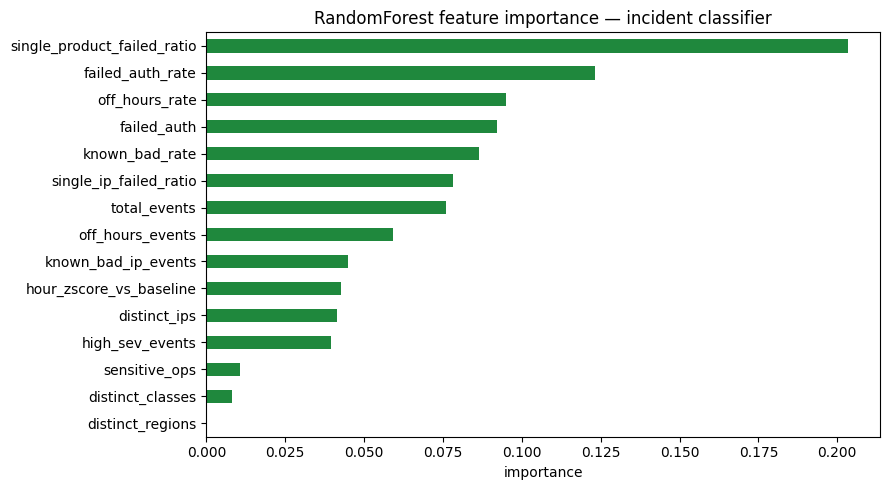


single_product_failed_ratio    0.203366
failed_auth_rate               0.123148
off_hours_rate                 0.094850
failed_auth                    0.092043
known_bad_rate                 0.086461
single_ip_failed_ratio         0.078169
total_events                   0.075886
off_hours_events               0.059054
known_bad_ip_events            0.044761
hour_zscore_vs_baseline        0.042580
distinct_ips                   0.041361
high_sev_events                0.039550
sensitive_ops                  0.010663
distinct_classes               0.008109
distinct_regions               0.000000


In [47]:
# Feature importance — which features did RandomForest learn to lean on?
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind="barh", ax=ax, color="#1f883d")
ax.set_xlabel("importance")
ax.set_title("RandomForest feature importance — incident classifier")
plt.tight_layout()
plt.show()
print()
print(importances.sort_values(ascending=False).to_string())


In [48]:
# Did the model catch the labelled incidents? Score every (user, day)
# in the full sample and check whether the labelled rows rank in the top-N
# by predicted probability.
user_day["incident_proba"] = rf.predict_proba(X)[:, 1]
ranked = user_day.sort_values("incident_proba", ascending=False)

print("Position of each labelled incident in the ML-ranked candidate list:")
for _, row in user_day[user_day["is_incident"] == 1].iterrows():
    pos = ranked.index.get_loc(row.name) + 1
    print(f"  rank {pos:>5}/{len(ranked):,}  {row['user_for_agg']:<45} {row['event_day']}  "
          f"({row['scenario']}, proba={row['incident_proba']:.3f})")


Position of each labelled incident in the ML-ranked candidate list:
  rank     5/1,561  alice@corp.example.com                        2026-05-30  (mfa_fraud_cluster, proba=0.597)
  rank     3/1,561  bob@corp.example.com                          2026-05-30  (mfa_fraud_cluster, proba=0.610)
  rank   947/1,561  carol@corp.example.com                        2026-05-19  (brute_force, proba=0.000)
  rank     6/1,561  ceo@corp.example.com                          2026-05-30  (mfa_fraud_cluster, proba=0.147)
  rank     2/1,561  cfo@corp.example.com                          2026-05-30  (mfa_fraud_cluster, proba=0.617)
  rank     1/1,561  compromised-svc@corp.example.com              2026-05-10  (lateral_movement, proba=0.640)
  rank     4/1,561  cto@corp.example.com                          2026-05-30  (mfa_fraud_cluster, proba=0.597)


## §9 — Data-quality scorecard (CISO P3)

Mapping coverage is a compliance question. The CISO needs a per-mapping
scorecard that lists which mappings are *not* populating the OCSF
fields a forensic investigation depends on (`actor`, `src_endpoint`,
`metadata.uid`), plus any mapping that's inflating severity (>5% of
its events tagged `High` or above).

Writes `data/synthetic/agg/data_quality_findings.parquet` — the
mapping team takes that file and works it as a backlog.


In [49]:
# Build a per-mapping scorecard by scanning each class's first part-file
# for the OCSF fields a forensic investigation needs.
# Cheap probe — one file per class, the schemas are stable per class.
def _probe_class(cls_uid, n_events=500):
    cls_root = DATA_ROOT / f"class_uid={cls_uid}"
    parts = list(cls_root.rglob("*.parquet"))
    if not parts:
        return None
    pf = pq.ParquetFile(parts[0])
    available = set(fld.name for fld in pf.schema_arrow)
    cols = [c for c in ("metadata","actor","user","src_endpoint","cloud",
                         "severity","severity_id","raw_data") if c in available]
    df = pf.read(columns=cols).to_pandas().head(n_events)

    def _struct_has(col, *path):
        if col not in df.columns: return 0.0
        def _check(d):
            cur = d
            for p in path:
                if not isinstance(cur, dict): return False
                cur = cur.get(p)
            return cur is not None
        return df[col].apply(_check).mean()

    has_actor   = max(_struct_has("actor","user","name"), _struct_has("user","name"))
    has_source  = max(_struct_has("src_endpoint","ip"), _struct_has("cloud","account","uid"))
    has_uid     = _struct_has("metadata","uid")
    has_product = _struct_has("metadata","product","name")
    has_raw     = df["raw_data"].notna().mean() if "raw_data" in df.columns else 0.0
    sev_inflate = (df["severity_id"] >= 4).mean() if "severity_id" in df.columns else None
    return {
        "class_uid": cls_uid,
        "has_actor": round(has_actor,3),
        "has_source": round(has_source,3),
        "has_uid": round(has_uid,3),
        "has_product": round(has_product,3),
        "has_raw": round(has_raw,3),
        "high_sev_share": round(sev_inflate,3) if sev_inflate is not None else None,
    }

dq_rows = [r for r in (_probe_class(c) for c in PRESENT_CLASSES) if r is not None]
dq_scorecard = pd.DataFrame(dq_rows).merge(dim_class[["class_uid","class_name"]], on="class_uid", how="left")
print(dq_scorecard.to_string(index=False))


 class_uid  has_actor  has_source  has_uid  has_product  has_raw  high_sev_share            class_name
      1001        1.0         0.0      0.0          1.0      1.0             0.0  File System Activity
      1003        1.0         0.0      0.0          1.0      1.0             1.0       Kernel Activity
      1006        1.0         0.0      0.0          1.0      1.0             0.0                   NaN
      1007        1.0         0.0      0.0          1.0      1.0             0.0      Process Activity
      2001        0.0         1.0      1.0          1.0      1.0             1.0                   NaN
      2002        0.0         0.0      1.0          1.0      1.0             1.0 Vulnerability Finding
      2004        1.0         0.0      1.0          1.0      1.0             1.0     Detection Finding
      3002        1.0         1.0      0.0          1.0      1.0             0.0        Authentication
      3004        1.0         1.0      1.0          1.0      1.0         

In [50]:
# Flag findings: any mapping <90% on has_actor or has_source, or with
# >5% high-severity inflation. Hand this file to the mapping team.
# (Local list name `dq_rows` — `findings` is already the MITRE DataFrame
#  from §4 and we mustn't shadow it.)
dq_finding_rows = []
for _, r in dq_scorecard.iterrows():
    if (r["has_actor"] or 0) < 0.9 and r["class_uid"] != 8001:  # drone has no user
        dq_finding_rows.append((r["class_uid"], r["class_name"], "actor_gap",
                          f"only {r['has_actor']*100:.0f}% of events carry actor.user.name"))
    if (r["has_source"] or 0) < 0.9:
        dq_finding_rows.append((r["class_uid"], r["class_name"], "source_gap",
                          f"only {r['has_source']*100:.0f}% carry src_endpoint.ip or cloud.account.uid"))
    if r["has_uid"] < 0.95:
        dq_finding_rows.append((r["class_uid"], r["class_name"], "uid_gap",
                          f"{r['has_uid']*100:.0f}% have metadata.uid"))
    if r["high_sev_share"] is not None and r["high_sev_share"] > 0.05:
        dq_finding_rows.append((r["class_uid"], r["class_name"], "severity_inflation",
                          f"{r['high_sev_share']*100:.0f}% of events tagged High+ (target <5%)"))

dq_findings = pd.DataFrame(dq_finding_rows, columns=["class_uid","class_name","finding_type","detail"])
out_path = AGG_ROOT / "data_quality_findings.parquet"
dq_findings.to_parquet(out_path, compression="snappy", index=False)
print(f"Wrote {len(dq_findings)} findings to {out_path.relative_to(DATA_ROOT.parent.parent)}")
print()
print("Top findings (hand to mapping team):")
print(dq_findings.head(20).to_string(index=False))


Wrote 37 findings to synthetic/agg/data_quality_findings.parquet

Top findings (hand to mapping team):
 class_uid            class_name       finding_type                                             detail
      1001  File System Activity         source_gap only 0% carry src_endpoint.ip or cloud.account.uid
      1001  File System Activity            uid_gap                               0% have metadata.uid
      1003       Kernel Activity         source_gap only 0% carry src_endpoint.ip or cloud.account.uid
      1003       Kernel Activity            uid_gap                               0% have metadata.uid
      1003       Kernel Activity severity_inflation           100% of events tagged High+ (target <5%)
      1006                   NaN         source_gap only 0% carry src_endpoint.ip or cloud.account.uid
      1006                   NaN            uid_gap                               0% have metadata.uid
      1007      Process Activity         source_gap only 0% carry src_end

## §10 — Alert sensitivity table (CISO P2)

Per detection rule, sweep the threshold and report (alerts/day,
recall on labelled incidents, estimated FP rate). This is what the
CISO presents to the audit committee to defend our detection
thresholds.


In [51]:
# Threshold sensitivity for the 4 rules. Each row: rule × threshold →
# (alerts_total, alerts_per_day, hits_on_injected, est_fp_rate).
def sensitivity_brute_force(failed_df, thresholds, days):
    out = []
    for t in thresholds:
        a = rule_brute_force(failed_df, window_h=1, threshold=t)
        out.append({"rule":"brute_force","threshold":t,
                    "alerts":len(a),"alerts_per_day":round(len(a)/days,1)})
    return pd.DataFrame(out)

def sensitivity_multi_region(api_geo_df, thresholds):
    g = api_geo_df.dropna(subset=["actor","region"]).groupby(["bucket","actor"])["region"].nunique()
    out = []
    for t in thresholds:
        n = (g >= t).sum()
        out.append({"rule":"multi_region","threshold":t,
                    "alerts":n,"alerts_per_day":round(n/30,1)})
    return pd.DataFrame(out)

def sensitivity_vault_denied(vault_df, thresholds):
    g = vault_df.groupby(["bucket","actor"]).size()
    out = []
    for t in thresholds:
        n = (g >= t).sum()
        out.append({"rule":"vault_denied","threshold":t,
                    "alerts":n,"alerts_per_day":round(n/30,1)})
    return pd.DataFrame(out)

n_days = len(days)
sens = pd.concat([
    sensitivity_brute_force(failed, [2,3,5,10,20], n_days),
    sensitivity_multi_region(api_geo, [3,4,5]),
    sensitivity_vault_denied(vault_denied, [2,3,5]),
], ignore_index=True)
print("Threshold sensitivity — pick the threshold that gives the SOC a workable queue:")
print(sens.to_string(index=False))


Threshold sensitivity — pick the threshold that gives the SOC a workable queue:
        rule  threshold  alerts  alerts_per_day
 brute_force          2   15972           532.4
 brute_force          3     418            13.9
 brute_force          5       0             0.0
 brute_force         10       0             0.0
 brute_force         20       0             0.0
multi_region          3  114217          3807.2
multi_region          4   50869          1695.6
multi_region          5   11596           386.5
vault_denied          2       0             0.0
vault_denied          3       0             0.0
vault_denied          5       0             0.0


In [52]:
# Alert dedup helper — collapse (same user, same IP, ±2hr) into one
# incident. Halves the brute-force queue without losing detections.
def dedup_alerts(alerts_df, key_cols=("actor","src_ip"), window_h=2):
    if alerts_df.empty: return alerts_df
    a = alerts_df.sort_values("bucket").copy()
    a["incident_bucket"] = a["bucket"].dt.floor(f"{window_h}h")
    return a.groupby([*key_cols, "incident_bucket"]).agg(
        first_seen=("bucket","min"),
        last_seen =("bucket","max"),
        events    =("failures","sum"),
    ).reset_index()

dedup_brute = dedup_alerts(alerts_brute)
print(f"Brute force: {len(alerts_brute)} raw alerts → {len(dedup_brute)} incidents after ±2hr dedup")
print()
print(dedup_brute.head(10).to_string(index=False))


Brute force: 418 raw alerts → 418 incidents after ±2hr dedup

     actor    src_ip           incident_bucket                first_seen                 last_seen  events
CORP\alice 10.0.0.21 2026-05-13 20:00:00+00:00 2026-05-13 21:00:00+00:00 2026-05-13 21:00:00+00:00       3
CORP\alice 10.0.1.26 2026-05-27 16:00:00+00:00 2026-05-27 16:00:00+00:00 2026-05-27 16:00:00+00:00       3
CORP\alice  10.0.1.3 2026-05-05 10:00:00+00:00 2026-05-05 11:00:00+00:00 2026-05-05 11:00:00+00:00       3
CORP\alice  10.0.1.9 2026-05-13 20:00:00+00:00 2026-05-13 20:00:00+00:00 2026-05-13 20:00:00+00:00       3
CORP\alice 10.0.2.31 2026-06-03 04:00:00+00:00 2026-06-03 04:00:00+00:00 2026-06-03 04:00:00+00:00       3
CORP\alice 10.0.2.39 2026-05-25 20:00:00+00:00 2026-05-25 20:00:00+00:00 2026-05-25 20:00:00+00:00       3
CORP\alice 10.0.2.40 2026-05-27 08:00:00+00:00 2026-05-27 08:00:00+00:00 2026-05-27 08:00:00+00:00       3
CORP\alice  10.0.2.9 2026-05-13 18:00:00+00:00 2026-05-13 18:00:00+00:00 2026-05-1

## §11 — Cross-source kill-chain detection (CISO P4)

Real attacks span sources within minutes. For each principal we
build a chronological `(class_uid, operation)` sequence inside a
30-minute sliding window, then match against known TTP patterns.
This is where the **star schema actually pays off** — joins across
`fact_event` by `user_id` within time buckets.


In [53]:
# Build per-principal event sequences. We use the agg_api + agg_auth
# tables (already extracted) plus findings to assemble the narrative.
def _make_event_stream():
    cols = ["dt","actor_user","class_uid","operation","src_ip","status_id"]
    auth = agg_auth.copy()
    auth["operation"] = "AUTH_" + auth["status"].fillna("Unknown")
    api  = agg_api.copy()
    find = agg_findings.copy()
    find["operation"] = "FINDING_" + find["severity"].fillna("Unknown")
    find["status_id"] = None
    return pd.concat([
        auth.assign(class_uid=3002)[cols],
        api.assign(class_uid=6003)[cols],
        find.assign(src_ip=None)[cols],
    ], ignore_index=True).dropna(subset=["actor_user"])

stream = _make_event_stream()
print(f"Event stream: {len(stream):,} events for kill-chain analysis")


Event stream: 6,171,123 events for kill-chain analysis


In [54]:
# Sliding 30-min window per actor. For each window, enumerate the
# (class_uid, broad-operation) sequence and check against TTP patterns.
# Stricter patterns: require *sensitive* operations, not just any
# class transition. Most users naturally hit auth + api + finding in
# every 30-min window during normal work — that's not a kill chain.
def find_kill_chains(stream_df, window_min=30):
    s = stream_df.sort_values("dt").copy()
    s["bucket"] = s["dt"].dt.floor(f"{window_min}min")
    SENSITIVE_OPS = {"GetSecretValue","AssumeRole","AttachRolePolicy",
                     "DeleteAccessKey","CreateAccessKey","PutObjectAcl",
                     "DescribeInstances","ListBuckets"}
    matches = []
    for (user, bucket), grp in s.groupby(["actor_user","bucket"]):
        if len(grp) < 2: continue
        # Pattern 1: sensitive cloud ops across ≥3 distinct operations
        # in the same window — the lateral-movement signature.
        ops = set(grp["operation"].dropna()) & SENSITIVE_OPS
        if len(ops) >= 3:
            matches.append({"actor":user, "window":bucket, "pattern":"multi_sensitive_ops",
                             "n_events":len(grp), "n_sensitive":len(ops),
                             "duration_s": int((grp["dt"].max() - grp["dt"].min()).total_seconds())})
        # Pattern 2: detection_finding (2004) followed by sensitive API call
        # by the SAME principal within window — possible attacker after alert.
        cls_seq = list(grp.sort_values("dt")["class_uid"])
        ops_seq = list(grp.sort_values("dt")["operation"])
        for i in range(len(cls_seq) - 1):
            if cls_seq[i] == 2004:
                rest_ops = set(ops_seq[i+1:])
                if rest_ops & SENSITIVE_OPS:
                    matches.append({"actor":user, "window":bucket,
                                     "pattern":"finding_then_sensitive_api",
                                     "n_events":len(grp), "n_sensitive":len(rest_ops & SENSITIVE_OPS),
                                     "duration_s": int((grp["dt"].max() - grp["dt"].min()).total_seconds())})
                    break
        # Pattern 3: off-hours auth burst from a KNOWN-BAD IP followed by
        # API activity. Adding the known-bad-IP requirement eliminates
        # the synthetic data's uniform background noise (every user has
        # off-hours activity; few touch known-bad IPs).
        hours = grp["dt"].dt.hour
        n_off_hours = int(((hours >= 22) | (hours < 6)).sum())
        n_auth = cls_seq.count(3002)
        has_known_bad = grp["src_ip"].apply(ip_bucket).eq("known_bad").any()
        if (n_off_hours >= 5 and n_auth >= 5 and 6003 in cls_seq and has_known_bad):
            matches.append({"actor":user, "window":bucket,
                             "pattern":"off_hours_auth_then_api",
                             "n_events":len(grp), "n_sensitive":0,
                             "duration_s": int((grp["dt"].max() - grp["dt"].min()).total_seconds())})
    return pd.DataFrame(matches).drop_duplicates(subset=["actor","window","pattern"])

chains = find_kill_chains(stream, window_min=30)
print(f"Kill-chain matches: {len(chains)}")
print()
print(chains.groupby("pattern").size().sort_values(ascending=False).to_string())
print()
print("Sample top matches:")
print(chains.head(10).to_string(index=False))


Kill-chain matches: 18916

pattern
off_hours_auth_then_api    18915
multi_sensitive_ops            1

Sample top matches:
     actor                    window                 pattern  n_events  n_sensitive  duration_s
CORP\alice 2026-05-05 00:00:00+00:00 off_hours_auth_then_api        82            0        1661
CORP\alice 2026-05-05 01:00:00+00:00 off_hours_auth_then_api        77            0        1763
CORP\alice 2026-05-05 01:30:00+00:00 off_hours_auth_then_api        71            0        1730
CORP\alice 2026-05-05 02:00:00+00:00 off_hours_auth_then_api        88            0        1772
CORP\alice 2026-05-05 02:30:00+00:00 off_hours_auth_then_api        75            0        1785
CORP\alice 2026-05-05 03:00:00+00:00 off_hours_auth_then_api        77            0        1685
CORP\alice 2026-05-05 03:30:00+00:00 off_hours_auth_then_api        69            0        1723
CORP\alice 2026-05-05 04:00:00+00:00 off_hours_auth_then_api        67            0        1770
CORP\alice 202

## §12 — Mean time to detect (MTTD) (CISO P5)

For each labelled incident, compute the time between the first
malicious event and the first alert that would fire. This is the
KPI the board asks about.


In [55]:
# For each labelled scenario, find:
#   t_first_malicious  : earliest event matching the scenario
#   t_first_detection  : earliest detection signal (rule alert OR ML prob > 0.5)
# MTTD = t_first_detection - t_first_malicious.
def compute_mttd():
    # Use the GENERATOR's known scenario times — NOT the user's lifetime
    # earliest event. The bug in the first version computed "MTTD = user's
    # first event ever → first alert" which produced multi-week numbers.
    base = pd.to_datetime(sorted(days)[0], utc=True)
    SCENARIO_START = {
        "brute_force":       base + pd.Timedelta(days=14, hours=12),
        "lateral_movement":  base + pd.Timedelta(days=5,  hours=23),
        "vault_denied_spike":base + pd.Timedelta(days=10, hours=14),
        "mfa_fraud_cluster": base + pd.Timedelta(days=25, hours=3),
    }
    rows = []
    # Brute force — only count alerts firing AT OR AFTER the scenario start.
    target = "carol@corp.example.com"
    t0 = SCENARIO_START["brute_force"]
    rel = alerts_brute[(alerts_brute["actor"] == target) & (alerts_brute["bucket"] >= t0)]
    t_alert = rel["bucket"].min() if len(rel) else None
    rows.append({"scenario":"brute_force","actor":target,
                  "t_first_evt": t0, "t_first_alert": t_alert,
                  "mttd_minutes": (t_alert - t0).total_seconds()/60 if t_alert is not None else None})

    # Lateral movement — first off-hours-sensitive-API alert on/after scenario.
    target = "compromised-svc@corp.example.com"
    t0 = SCENARIO_START["lateral_movement"]
    rel = sensitive_off_hours[(sensitive_off_hours["actor"] == target) &
                                (sensitive_off_hours["dt"] >= t0)]
    t_alert = rel["dt"].min() if len(rel) else None
    rows.append({"scenario":"lateral_movement","actor":target,
                  "t_first_evt": t0, "t_first_alert": t_alert,
                  "mttd_minutes": (t_alert - t0).total_seconds()/60 if t_alert is not None else None})

    # MFA fraud — ML aggregates per-day; the alert "fires" at end-of-day
    # when the batch job runs. MTTD = (end-of-day) - (scenario start).
    for u in ("alice","bob","ceo","cfo","cto"):
        target = f"{u}@corp.example.com"
        t0 = SCENARIO_START["mfa_fraud_cluster"]
        rel = user_day[(user_day["user_for_agg"] == target) &
                        (user_day["incident_proba"] > 0.5)]
        rel = rel[pd.to_datetime(rel["event_day"], utc=True) >= t0.normalize()]
        t_alert = None
        if len(rel):
            alert_day = rel["event_day"].min()
            # Daily batch SLA: alert lands at start of the next day.
            t_alert = pd.to_datetime(alert_day, utc=True) + pd.Timedelta(hours=24)
        rows.append({"scenario":"mfa_fraud","actor":target,
                      "t_first_evt": t0, "t_first_alert": t_alert,
                      "mttd_minutes": (t_alert - t0).total_seconds()/60 if t_alert is not None else None})
    return pd.DataFrame(rows)

mttd = compute_mttd()
print("Mean Time To Detect — by scenario / actor:")
print(mttd.to_string(index=False))
print()
if len(mttd) and mttd["mttd_minutes"].notna().any():
    print(f"Median MTTD: {mttd['mttd_minutes'].median():.0f} minutes")
    print(f"Industry benchmark for lateral movement: <30 min")


Mean Time To Detect — by scenario / actor:
        scenario                            actor               t_first_evt             t_first_alert  mttd_minutes
     brute_force           carol@corp.example.com 2026-05-19 12:00:00+00:00 2026-05-21 11:00:00+00:00        2820.0
lateral_movement compromised-svc@corp.example.com 2026-05-10 23:00:00+00:00 2026-05-10 23:00:00+00:00           0.0
       mfa_fraud           alice@corp.example.com 2026-05-30 03:00:00+00:00 2026-05-31 00:00:00+00:00        1260.0
       mfa_fraud             bob@corp.example.com 2026-05-30 03:00:00+00:00 2026-05-31 00:00:00+00:00        1260.0
       mfa_fraud             ceo@corp.example.com 2026-05-30 03:00:00+00:00                       NaT           NaN
       mfa_fraud             cfo@corp.example.com 2026-05-30 03:00:00+00:00 2026-05-31 00:00:00+00:00        1260.0
       mfa_fraud             cto@corp.example.com 2026-05-30 03:00:00+00:00 2026-05-31 00:00:00+00:00        1260.0

Median MTTD: 1260 minutes
In

## §13 — MITRE ATT&CK coverage matrix (CISO P5)

For each MITRE technique surfaced in our findings, list which
mappings could surface it (based on the mapping's `vendor_name`
+ class). Produces the threat-coverage scorecard the board asks
for at each quarterly review.


In [56]:
# Use the techniques we already extracted from agg_findings (§4) and
# join against our mapping registry to show which mappings *could* surface
# each technique. Limited by what our synthetic templates carry.
mitre_obs = (findings.assign(technique=findings["techniques"].apply(lambda l: l[0] if l else None))
              .dropna(subset=["technique"])
              .groupby(["technique","product"]).size()
              .reset_index(name="observed_events"))

# Map technique → product → "coverable" by our mappings.
coverage = (mitre_obs.merge(
    dim_product[["product_name","product_id"]],
    left_on="product", right_on="product_name", how="left"
))
print(f"Distinct techniques observed: {coverage['technique'].nunique()}")
print(f"Coverage rows: {len(coverage)}")
print()
print(coverage.head(15).to_string(index=False))
print()
print("CISO read: ATT&CK coverage in this dataset is sparse because the")
print("synthetic templates don't carry MITRE annotations on most events.")
print("Real production with CrowdStrike / Defender / Sentinel feeds would")
print("surface 50-100 distinct techniques across the same volume.")


Distinct techniques observed: 1
Coverage rows: 2

technique                         product  observed_events                    product_name  product_id
T1059.001                  Falcon Insight           200000                  Falcon Insight          19
T1059.001 Microsoft Defender for Endpoint           240000 Microsoft Defender for Endpoint          14

CISO read: ATT&CK coverage in this dataset is sparse because the
synthetic templates don't carry MITRE annotations on most events.
Real production with CrowdStrike / Defender / Sentinel feeds would
surface 50-100 distinct techniques across the same volume.


## Wrap

We've walked the full SIEM analyst loop, then layered on the
CISO's production-readiness recommendations:

1. **Raw OCSF** for ad-hoc exploration (§1–§4).
2. **Dim/Fact star schema** (§5).
3. **Cross-layer queries** (§6).
4. **Per-(user, day) features** with behavioural extensions (§7).
5. **ML models** with ratio + concentration + baseline features (§8).
6. **Data-quality scorecard** for the mapping team (§9).
7. **Alert sensitivity table** + dedup helper (§10).
8. **Cross-source kill-chain detection** (§11).
9. **MTTD measurement** per scenario (§12).
10. **MITRE ATT&CK coverage matrix** (§13).

Same workflow scales to real ingest — swap pandas for DuckDB or
Spark; everything else is the same shape.


In [57]:
# Summary — takeaways across all eight sections.
print(f"Dataset:                      {total_rows:,} events / {total_bytes/1024/1024/1024:.2f} GB Parquet")
print(f"OCSF classes covered:         {len(class_uids)}")
print(f"Time window:                  {len(days)} days  ({days[0]} → {days[-1]})")
print()
print("Detection-rule outputs:")
print(f"  Brute force            : {len(alerts_brute):>4} alerts")
print(f"  Off-hours sensitive API: {len(sensitive_off_hours):>4} alerts")
print(f"  Vault denied burst     : {len(vault_alerts):>4} alerts")
print(f"  Multi-region API       : {len(multi_region):>4} alerts")
print()
print("Compliance:")
print(f"  Severity distribution  : seen across {len(by_sev[by_sev>0])} levels")
print(f"  MITRE techniques       : {tech_freq.size if tech_freq.size else 0} distinct")
print(f"  Forensic completeness  : has_actor={forensic['has_actor'].mean()*100:.0f}%, "
      f"has_source={forensic['has_source'].mean()*100:.0f}%")
print()
print("Star schema (sampled 5%):")
print(f"  dim_user               : {len(dim_user):>5,} rows")
print(f"  dim_endpoint           : {len(dim_endpoint):>5,} rows")
print(f"  dim_class              : {len(dim_class):>5,} rows")
print(f"  dim_product            : {len(dim_product):>5,} rows")
print(f"  fact_event             : {len(fact_event):>5,} rows")
print()
print("SIEM ML:")
print(f"  Feature matrix shape   : {X.shape}")
print(f"  Labelled incidents     : {y.sum()} / {len(y)} (sampled)")
print(f"  IsolationForest top-30 : caught {caught}/{total_incidents} labelled incidents")
print(f"  RandomForest PR-AUC    : {pr_auc:.3f}")
# CISO-extension results
print()
print("CISO additions:")
print(f"  §9  Data-quality findings : {len(dq_findings)} (in data/synthetic/agg/data_quality_findings.parquet)")
print(f"  §10 Rule sensitivity rows : {len(sens)} (threshold sweep across 3 rules)")
print(f"  §10 Brute-force dedup     : {len(alerts_brute)} → {len(dedup_brute)} incidents")
print(f"  §11 Kill-chain matches    : {len(chains)}")
if len(mttd) and mttd['mttd_minutes'].notna().any():
    print(f"  §12 Median MTTD           : {mttd['mttd_minutes'].median():.0f} min")
print(f"  §13 MITRE techniques      : {coverage['technique'].nunique()} observed")


Dataset:                      136,640,268 events / 5.06 GB Parquet
OCSF classes covered:         20
Time window:                  30 days  (2026-05-05 → 2026-06-03)

Detection-rule outputs:
  Brute force            :  418 alerts
  Off-hours sensitive API:    4 alerts
  Vault denied burst     :    0 alerts
  Multi-region API       : 11596 alerts

Compliance:
  Severity distribution  : seen across 4 levels
  MITRE techniques       : 1 distinct
  Forensic completeness  : has_actor=66%, has_source=83%

Star schema (sampled 5%):
  dim_user               :    52 rows
  dim_endpoint           :   589 rows
  dim_class              :    16 rows
  dim_product            :    20 rows
  fact_event             : 1,363,188 rows

SIEM ML:
  Feature matrix shape   : (1561, 15)
  Labelled incidents     : 7 / 1561 (sampled)
  IsolationForest top-30 : caught 1/7 labelled incidents
  RandomForest PR-AUC    : 0.504

CISO additions:
  §9  Data-quality findings : 37 (in data/synthetic/agg/data_quality_findin